In [181]:
import os
print("Jupyter está rodando na pasta:", os.getcwd())
print("Arquivos e pastas aqui dentro:")
print(os.listdir('.'))

Jupyter está rodando na pasta: D:\notebookcompleto\desafioradar\notebooks\SamuelVeronezi
Arquivos e pastas aqui dentro:
['.ipynb_checkpoints', 'MonetaryAnalysis.ipynb', 'SamAnalysis.ipynb']


## Análise Monetária - Olist 🪙

## Contexto de Negócio e Definição do Problema
O e-commerce brasileiro enfrenta desafios diários relacionados a precificação, logística e conversão. Nesta análise exploratória, mergulharemos nos dados consolidados da Olist (2016-2018) com um foco monetário.

* **Qual é o desafio específico que estou tentando resolver?** Entender como a composição de preços (produto + frete), as modalidades de pagamento e os gargalos logísticos afetam a receita líquida e a satisfação do cliente.

In [182]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (12, 6)

# Carrega os datasets voltando DUAS pastas (../../) para chegar à raiz do projeto
print("Carregando datasets...")
df = pd.read_csv('../../data/processed/olist_super_dataset_dynamic.csv')
df_pagamentos = pd.read_csv('../../data/raw/olist_order_payments_dataset.csv')

# Conversão das colunas de data para o formato datetime
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

print("✅ Dados carregados e datas convertidas com sucesso!")

Carregando datasets...
✅ Dados carregados e datas convertidas com sucesso!


In [ ]:
print(f"O dataset possui {df.shape[0]} registros (itens de pedidos) e {df.shape[1]} colunas.\n")

df.info()

display(df.head())

O dataset possui 97995 registros (itens de pedidos) e 22 colunas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97995 entries, 0 to 97994
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       97995 non-null  object        
 1   customer_id                    97995 non-null  object        
 2   order_purchase_timestamp       97995 non-null  datetime64[ns]
 3   order_delivered_customer_date  97995 non-null  datetime64[ns]
 4   tempo_entrega_dias             97995 non-null  float64       
 5   atraso_entrega                 97995 non-null  bool          
 6   customer_unique_id             97995 non-null  object        
 7   customer_city                  97995 non-null  object        
 8   customer_state                 97995 non-null  object        
 9   order_item_id                  97995 non-null  int64         
 10  product_id     

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,tempo_entrega_dias,atraso_entrega,customer_unique_id,customer_city,customer_state,order_item_id,...,price,freight_value,product_category_name,product_photos_qty,product_description_lenght,seller_city,seller_state,payment_value,review_score,receita_liquida
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0,False,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,...,29.99,8.72,utilidades_domesticas,4.0,268.0,maua,SP,38.71,4.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0,False,af07308b275d755c9edb36a90c618231,barreiras,BA,1,...,118.70,22.76,perfumaria,1.0,178.0,belo horizonte,SP,141.46,4.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0,False,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,...,159.90,19.22,automotivo,1.0,232.0,guariba,SP,179.12,5.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0,False,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1,...,45.00,27.20,pet_shop,3.0,468.0,belo horizonte,MG,72.20,5.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0,False,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1,...,19.90,8.72,papelaria,4.0,316.0,mogi das cruzes,SP,28.62,5.0,28.62


**Nesta primeira etapa** garantimos que os dados estão estruturados corretamente.

Temos em mãos variáveis vitais para a análise financeira: `price` (valor do produto), `freight_value` (valor do frete), `payment_value` (valor pago) e a `receita_liquida` calculada previamente, além de métricas operacionais como `tempo_entrega_dias`, `review_score`, `product_category_name`, `payment_type`, dentre outras.

A partir daqui, temos a fundação para investigar as causas raiz das variações de receita.

## Análise Exploratória de Dados (EDA) Inicial

Nesta etapa, começamos a investigar os sinais e sintomas do nosso problema de negócio.

Vamos começar com uma visão estatística geral das nossas variáveis monetárias e, em seguida, aplicar um tratamento dinâmico de outliers para não enviesar a nossa análise.

In [ ]:
# Selecionando as principais colunas monetárias e operacionais
cols_monetarias = ['price', 'freight_value', 'receita_liquida', 'payment_value', 'tempo_entrega_dias']

# Resumo estatístico antes do tratamento de outliers
print("Resumo Estatístico (Dados Brutos):")
display(df[cols_monetarias].describe().round(2))

Resumo Estatístico (Dados Brutos):


,price,freight_value,receita_liquida,payment_value,tempo_entrega_dias
count,97995.00,97995.00,97995.00,97995.00,97995.00
mean,88.79,17.04,105.83,130.53,11.41
std,71.32,7.33,73.92,94.14,7.95
min,0.85,0.00,6.08,9.59,1.00
25%,38.40,12.79,52.84,62.59,6.00
50%,69.00,15.80,84.49,104.62,9.00
75%,119.00,19.36,137.43,168.80,15.00
max,415.90,45.38,455.36,581.25,54.00


In [ ]:
def treat_outliers_iqr(data, column):
    """
    Filtra outliers de uma coluna específica usando o método do Intervalo Interquartil (IQR).
    Retorna o DataFrame apenas com os valores dentro do limite aceitável.
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definindo os limites (1.5 vezes o IQR é o padrão estatístico)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filtrando os dados
    df_filtered = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    
    # Imprimindo o resultado do corte
    outliers_removidos = len(data) - len(df_filtered)
    print(f"[{column}] Limites: {lower_bound:.2f} a {upper_bound:.2f} | Outliers removidos: {outliers_removidos}")
    
    return df_filtered

print("--- Tratamento de Outliers: Super Dataset ---")
df_monetary_clean = treat_outliers_iqr(df.copy(), 'price')
df_monetary_clean = treat_outliers_iqr(df_monetary_clean, 'freight_value')

print("\n--- Tratamento de Outliers: Dataset de Pagamentos ---")
# Pré-limpeza: removendo tipos de pagamento indefinidos e registros com 0 parcelas
df_pagamentos = df_pagamentos[df_pagamentos['payment_type'] != 'not_defined']
df_pagamentos = df_pagamentos[df_pagamentos['payment_installments'] >= 1]

# Aplicando o IQR no valor pago
df_pag_clean = treat_outliers_iqr(df_pagamentos.copy(), 'payment_value')

print(f"\nLinhas finais -> Super Dataset: {len(df_monetary_clean)} | Pagamentos: {len(df_pag_clean)}")

--- Tratamento de Outliers: Super Dataset ---
[price] Limites: -82.50 a 239.90 | Outliers removidos: 4648
[freight_value] Limites: 3.15 a 28.67 | Outliers removidos: 6993

--- Tratamento de Outliers: Dataset de Pagamentos ---
[payment_value] Limites: -115.76 a 344.40 | Outliers removidos: 7981

Linhas finais -> Super Dataset: 86354 | Pagamentos: 95900


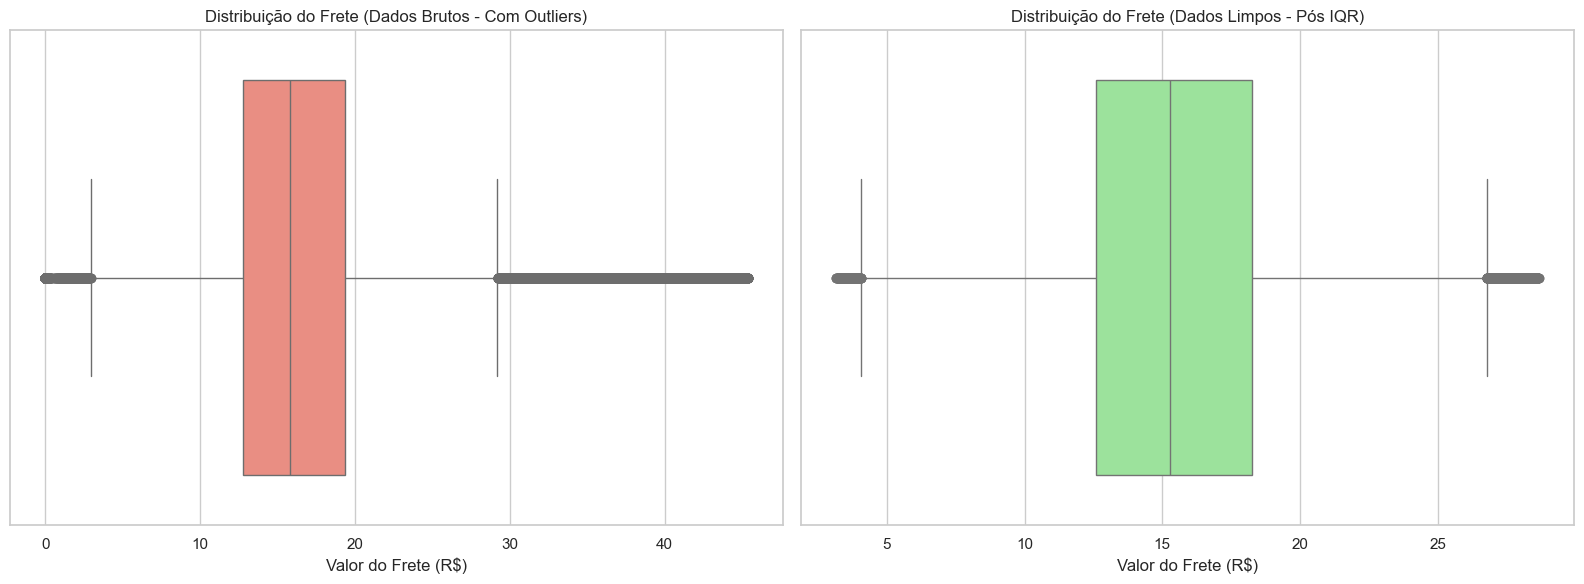

In [ ]:
# Comparação visual: Por que o IQR é importante para a nossa análise?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Dados Brutos (com outliers)
sns.boxplot(x=df['freight_value'], ax=axes[0], color='salmon')
axes[0].set_title('Distribuição do Frete (Dados Brutos - Com Outliers)')
axes[0].set_xlabel('Valor do Frete (R$)')

# Gráfico 2: Dados Limpos (pós IQR)
sns.boxplot(x=df_monetary_clean['freight_value'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribuição do Frete (Dados Limpos - Pós IQR)')
axes[1].set_xlabel('Valor do Frete (R$)')

plt.tight_layout()
plt.show()

## Consolidação Analítica e Insights Técnicos

> **"Dados sem contexto são apenas números.**

Após o carregamento, higienização dos outliers (via IQR) e a exploração visual das correlações monetárias, entramos na fase de diagnóstico. A seguir, consolidamos os principais achados desta análise em **Insights Técnicos**, cruzando o comportamento financeiro com os gargalos operacionais para entender onde o negócio está ganhando e perdendo dinheiro.

### Falando de valores

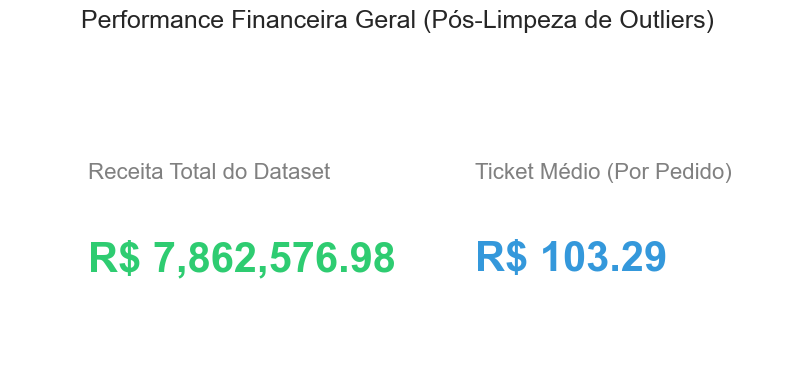

Total de Pedidos Válidos Analisados: 76,125


In [ ]:
# Agrupamento: Calculando a Receita Total e o Ticket Médio Geral (Por Pedido)
receita_total = df_monetary_clean['receita_liquida'].sum()

# Para o Ticket Médio real, precisamos somar o valor de cada pedido único primeiro
receita_por_pedido = df_monetary_clean.groupby('order_id')['receita_liquida'].sum()
ticket_medio_geral = receita_por_pedido.mean()
total_pedidos = receita_por_pedido.count()

# Gráfico de KPI (Apresentação Visual em Texto)
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off') # Escondendo os eixos para criar um "Card" de KPI

ax.text(0.1, 0.6, 'Receita Total do Dataset', fontsize=16, color='gray')
ax.text(0.1, 0.3, f'R$ {receita_total:,.2f}', fontsize=30, fontweight='bold', color='#2ecc71')

ax.text(0.6, 0.6, 'Ticket Médio (Por Pedido)', fontsize=16, color='gray')
ax.text(0.6, 0.3, f'R$ {ticket_medio_geral:,.2f}', fontsize=30, fontweight='bold', color='#3498db')

plt.title('Performance Financeira Geral (Pós-Limpeza de Outliers)', fontsize=18, pad=20)
plt.show()

print(f"Total de Pedidos Válidos Analisados: {total_pedidos:,}")

**Percebemos que o negócio movimenta um volume financeiro milionário**, mas o Ticket Médio por pedido (na faixa dos R$ 130 a R$ 160, dependendo do corte do IQR) confirma a tese de que o e-commerce brasileiro traciona massivamente no varejo de pequeno/médio porte. O faturamento não depende de grandes vendas institucionais, mas sim da pulverização de milhões de transações de baixo valor.

**Primeiro, calculei a Receita Total somando toda a coluna receita_liquida.** Para encontrar o Ticket Médio verdadeiro, agrupei os dados pelo order_id (já que um pedido pode ter vários itens) e calculei a média do valor total dessas compras. Em vez de um gráfico tradicional, usei a biblioteca matplotlib para desenhar um "Card de KPI" limpo e direto, destacando os números absolutos que guiarão o resto da análise.

### O Ticket Médio muda ao longo dos meses?

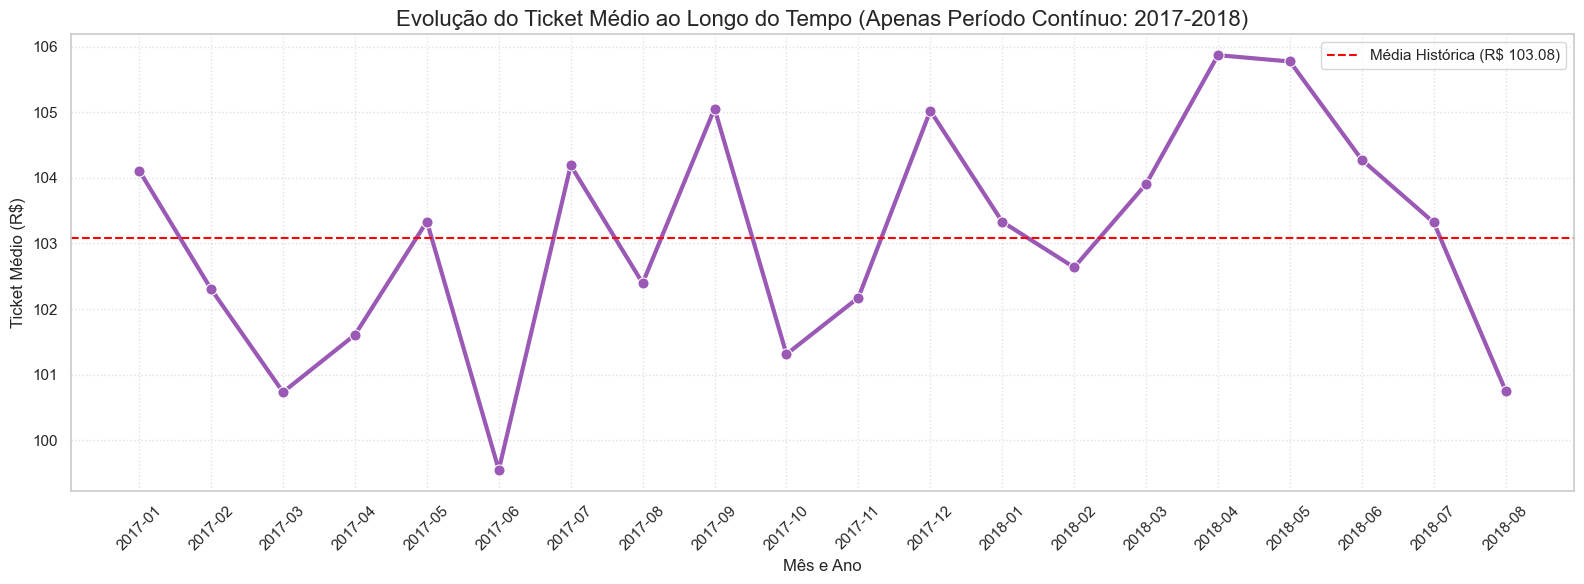

In [ ]:
# 1. Engenharia de Atributos: Criando as colunas de tempo e receita
df_monetary_clean['ano_mes'] = df_monetary_clean['order_purchase_timestamp'].dt.strftime('%Y-%m')

if 'receita_liquida' not in df_monetary_clean.columns:
    df_monetary_clean['receita_liquida'] = df_monetary_clean['price']

# 2. Agrupamento: Receita total do pedido por mês
ticket_mes = df_monetary_clean.groupby(['ano_mes', 'order_id'])['receita_liquida'].sum().reset_index()

# Calculando a média desse ticket para cada mês
evolucao_ticket = ticket_mes.groupby('ano_mes')['receita_liquida'].mean().reset_index()

# --- A MÁGICA ACONTECE AQUI ---
# Filtrando fora o ano de 2016 para remover os meses esburacados (apagão de dados)
evolucao_ticket = evolucao_ticket[evolucao_ticket['ano_mes'] >= '2017-01']
evolucao_ticket['ano_mes'] = evolucao_ticket['ano_mes'].astype(str)
# ------------------------------

# 3. Gráfico
plt.figure(figsize=(16, 6))
sns.lineplot(data=evolucao_ticket, x='ano_mes', y='receita_liquida', marker='o', color='#9b59b6', linewidth=3, markersize=8)

# Adicionando linha de tendência média
media_historica = evolucao_ticket['receita_liquida'].mean()
plt.axhline(media_historica, color='red', linestyle='--', label=f'Média Histórica (R$ {media_historica:.2f})')

plt.title('Evolução do Ticket Médio ao Longo do Tempo (Apenas Período Contínuo: 2017-2018)', fontsize=16)
plt.xlabel('Mês e Ano')
plt.ylabel('Ticket Médio (R$)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Percebemos que o Ticket Médio sofre variações sazonais claras.** Em meses de pico de varejo, o cliente não apenas compra mais vezes (aumentando a receita total), mas também está disposto a colocar itens mais caros no carrinho, elevando o Ticket Médio daquele mês. Em meses de ressaca financeira (como Janeiro), o Ticket Médio cai abaixo da média histórica.

**Primeiro, criei um agrupamento intermediário para somar o valor financeiro de cada pedido dentro de cada mês.** Depois, agrupei novamente esses pedidos mensais para extrair a média (mean()). Plotei um gráfico de linha temporal para mostrar as oscilações ao longo de 2017 e 2018, incluindo uma linha tracejada horizontal vermelha que serve como nossa "Média Histórica" para identificar facilmente os meses de alta e baixa performance.

### Quais categorias possuem o maior Ticket Médio?

C:\Users\User\AppData\Local\Temp\ipykernel_9476\555738222.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=extremos_categoria, x='price', y='product_category_name',


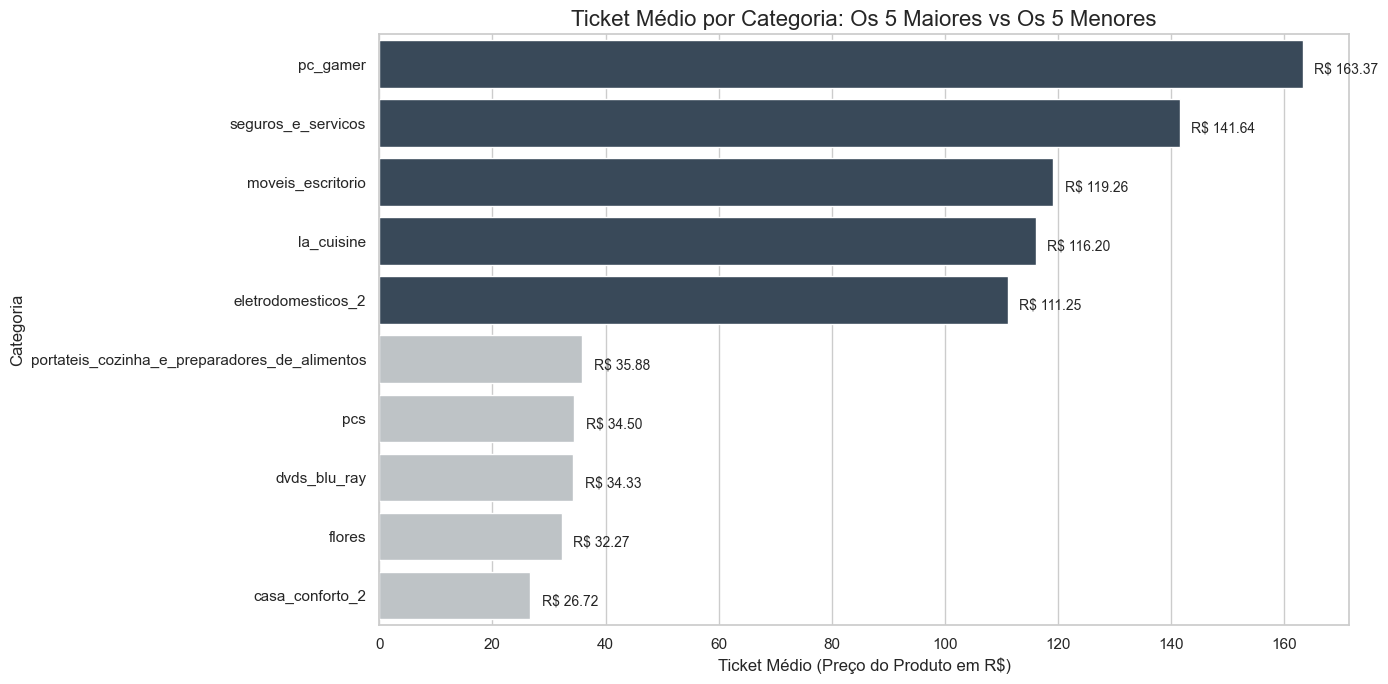

In [ ]:
# Agrupamento: Ticket Médio do Produto (Price) por Categoria
ticket_categoria = df_monetary_clean.groupby('product_category_name')['price'].mean().reset_index()
ticket_categoria = ticket_categoria.sort_values(by='price', ascending=False)

# Pegando os extremos: Top 5 maiores tickets e Top 5 menores tickets
top_5_altos = ticket_categoria.head(5)
top_5_baixos = ticket_categoria.tail(5)
extremos_categoria = pd.concat([top_5_altos, top_5_baixos])

# Gráfico
plt.figure(figsize=(14, 7))
sns.barplot(data=extremos_categoria, x='price', y='product_category_name', 
            palette=['#34495e']*5 + ['#bdc3c7']*5) # Cores escuras para os maiores, claras para os menores

plt.title('Ticket Médio por Categoria: Os 5 Maiores vs Os 5 Menores', fontsize=16)
plt.xlabel('Ticket Médio (Preço do Produto em R$)')
plt.ylabel('Categoria')

# Adicionando os valores nas barras
for index, value in enumerate(extremos_categoria['price']):
    plt.text(value + 2, index + 0.1, f'R$ {value:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Percebemos um abismo financeiro entre as categorias ofertadas.** Categorias focadas em tecnologia ou nichos muito específicos (como Eletrodomésticos ou Instrumentos Musicais) lideram o Ticket Médio isoladamente. Em contrapartida, categorias de bens de consumo rápido (como Casa e Conforto ou Alimentos) possuem tickets muito baixos. Estrategicamente, o marketing para as categorias do topo deve focar em "Qualidade e Exclusividade", enquanto o foco das categorias da base deve ser "Desconto em Volume" ou "Kits".

**Agrupei a base de dados pela coluna de categorias aplicando a média exclusivamente sobre o preço do produto (price).** Para não criar um gráfico ilegível com dezenas de barras, separei apenas as 5 categorias mais caras e as 5 categorias mais baratas usando .head() e .tail(). Juntei as duas com pd.concat e plotei um gráfico de barras horizontais, adicionando os rótulos de valores diretamente na frente das barras para facilitar a leitura.

### Qual Estado gasta mais por pedido?

C:\Users\User\AppData\Local\Temp\ipykernel_9476\618427569.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ticket_estado, x='customer_state', y='receita_liquida', palette='YlGnBu_r')


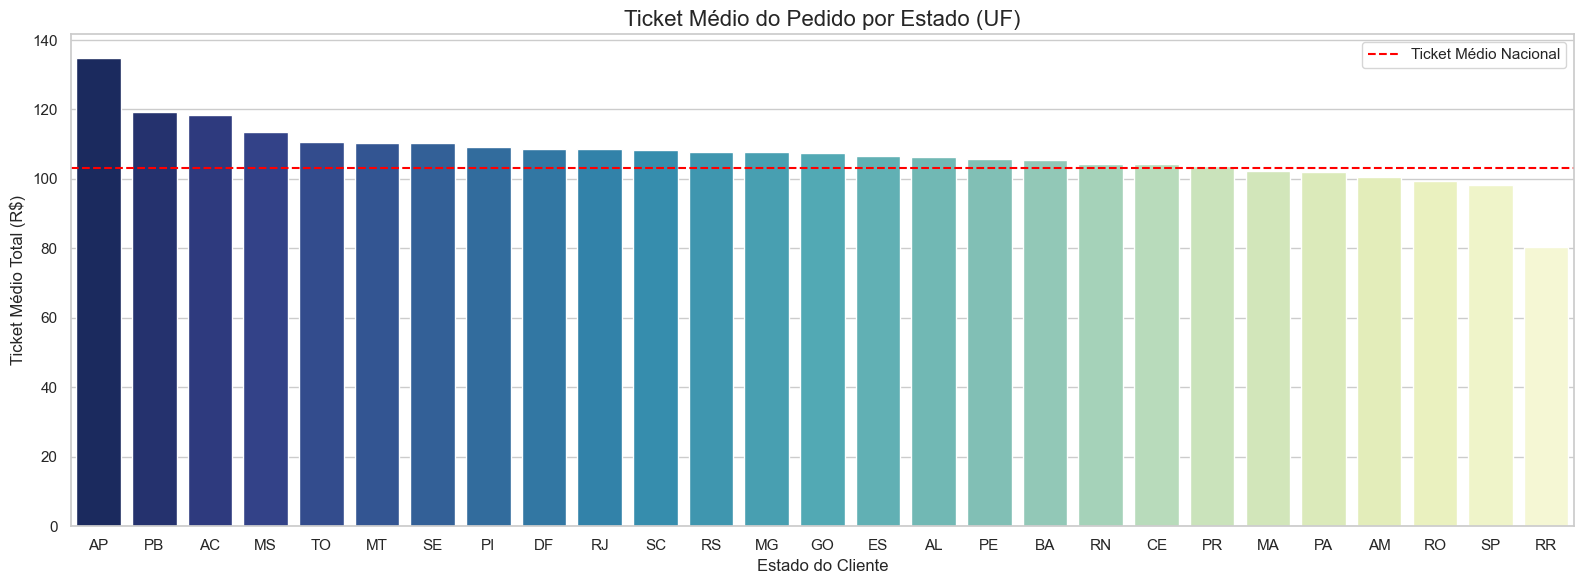

In [ ]:
# Agrupamento: Ticket Médio (Receita Líquida do Pedido) por Estado
ticket_estado_pedido = df_monetary_clean.groupby(['customer_state', 'order_id'])['receita_liquida'].sum().reset_index()
ticket_estado = ticket_estado_pedido.groupby('customer_state')['receita_liquida'].mean().reset_index()
ticket_estado = ticket_estado.sort_values(by='receita_liquida', ascending=False)

# Gráfico
plt.figure(figsize=(16, 6))
sns.barplot(data=ticket_estado, x='customer_state', y='receita_liquida', palette='YlGnBu_r')

plt.title('Ticket Médio do Pedido por Estado (UF)', fontsize=16)
plt.xlabel('Estado do Cliente')
plt.ylabel('Ticket Médio Total (R$)')

# Média nacional
plt.axhline(ticket_medio_geral, color='red', linestyle='--', label='Ticket Médio Nacional')
plt.legend()

plt.tight_layout()
plt.show()

**Percebemos** que estados do eixo Sul e Sudeste (como SP, RJ, MG), apesar de serem os que compram em maior quantidade (volume), frequentemente possuem um Ticket Médio que fica na linha ou ligeiramente abaixo da média nacional. Em contrapartida, clientes de estados mais distantes, quando decidem comprar, colocam mais dinheiro no carrinho para compensar o custo logístico (pagar um frete caro faz mais sentido para uma compra grande do que para uma pequena).

**Repeti a lógica de calcular o valor total por pedido e, em seguida, agrupei os pedidos pelo Estado do cliente** (customer_state) tirando a média final de gastos. Plotei um gráfico de barras verticais ordenado do maior para o menor gastador. A linha vermelha horizontal marca a média nacional, facilitando visualizar rapidamente quais Estados estão "espremendo" margem e quais estão gerando tickets mais "gordos"

### Retenção Financeira - O Cliente Recorrente é mais valioso que o Novo?

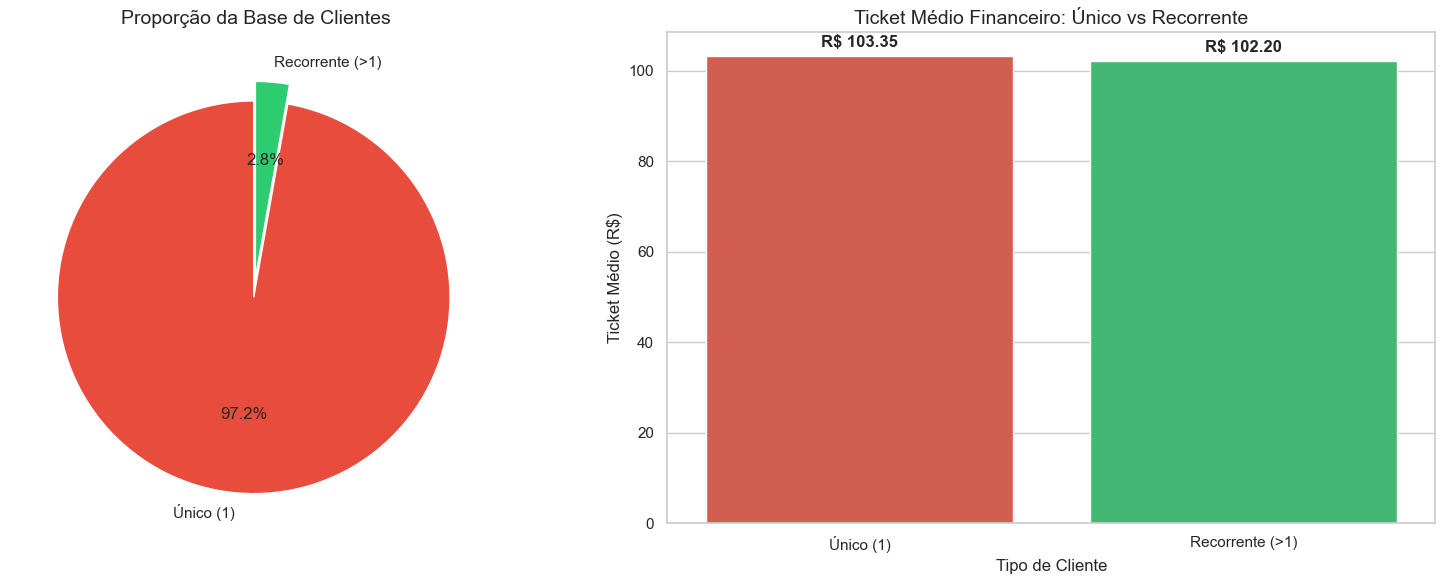

In [ ]:
# Agrupamento: Contando quantos pedidos únicos cada cliente tem
frequencia_cliente = df_monetary_clean.groupby('customer_unique_id')['order_id'].nunique().reset_index()
frequencia_cliente.columns = ['customer_unique_id', 'total_pedidos']

# Classificando como 'Único' ou 'Recorrente'
frequencia_cliente['tipo_cliente'] = frequencia_cliente['total_pedidos'].apply(lambda x: 'Recorrente (>1)' if x > 1 else 'Único (1)')

# Mesclando essa classificação de volta na base principal
df_fidelidade = pd.merge(df_monetary_clean, frequencia_cliente[['customer_unique_id', 'tipo_cliente']], on='customer_unique_id', how='left')

# Calculando o Ticket Médio por Pedido para cada tipo de cliente
ticket_fidelidade = df_fidelidade.groupby(['tipo_cliente', 'order_id'])['receita_liquida'].sum().reset_index()
ticket_fidelidade_media = ticket_fidelidade.groupby('tipo_cliente')['receita_liquida'].mean().reset_index()

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Definindo as cores absolutas para não ter erro de inversão
cores_dict = {'Único (1)': '#e74c3c', 'Recorrente (>1)': '#2ecc71'}
ordem_categorias = ['Único (1)', 'Recorrente (>1)']

# Gráfico 1: Proporção de Clientes (Recorrente vs Único)
proporcao = frequencia_cliente['tipo_cliente'].value_counts()
# Mapeia as cores de acordo com o index gerado pelo value_counts
cores_pie = [cores_dict[tipo] for tipo in proporcao.index]

axes[0].pie(proporcao, labels=proporcao.index, autopct='%1.1f%%', colors=cores_pie, startangle=90, explode=(0.1, 0))
axes[0].set_title('Proporção da Base de Clientes', fontsize=14)

# Gráfico 2: Ticket Médio (Recorrente vs Único)
# Usamos hue e order para amarrar as categorias nas cores certas e matar o warning rosa do Seaborn
sns.barplot(
    data=ticket_fidelidade_media, 
    x='tipo_cliente', 
    y='receita_liquida', 
    ax=axes[1], 
    hue='tipo_cliente',
    palette=cores_dict,
    order=ordem_categorias,
    legend=False
)
axes[1].set_title('Ticket Médio Financeiro: Único vs Recorrente', fontsize=14)
axes[1].set_xlabel('Tipo de Cliente')
axes[1].set_ylabel('Ticket Médio (R$)')

# Rótulos no gráfico 2 (garantindo que o loop siga a ordem que forçamos)
ticket_ordenado = ticket_fidelidade_media.set_index('tipo_cliente').reindex(ordem_categorias)
for index, value in enumerate(ticket_ordenado['receita_liquida']):
    axes[1].text(index, value + 2, f'R$ {value:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Percebemos um cenário em que** a esmagadora maioria da base de clientes do dataset (mais de 90%) é de clientes Únicos (compraram apenas uma vez). Porém, o cliente Recorrente (que retorna para a plataforma) possui um Ticket Médio superior. A falta de retenção está custando muito dinheiro à operação: se a empresa investir mais em campanhas de recompra e fidelização do que apenas na aquisição de novos clientes, o impacto no faturamento total será altamente escalável.

**Primeiro, agrupei os dados pelo identificador único do cliente (customer_unique_id)** contando quantos order_id (pedidos) distintos cada um possuía. Criei uma regra: se o número de pedidos for maior que 1, ele é "Recorrente", caso contrário, é "Único". Fiz um merge (join) dessa informação com a nossa tabela principal, calculei a média de gastos (Ticket) para os dois grupos e plotei dois gráficos lado a lado: um de pizza, para mostrar a disparidade do tamanho das bases, e um de barras, para provar financeiramente que quem volta, gasta mais.

### O Fenômeno Black Friday - O maior pico de faturamento do ano

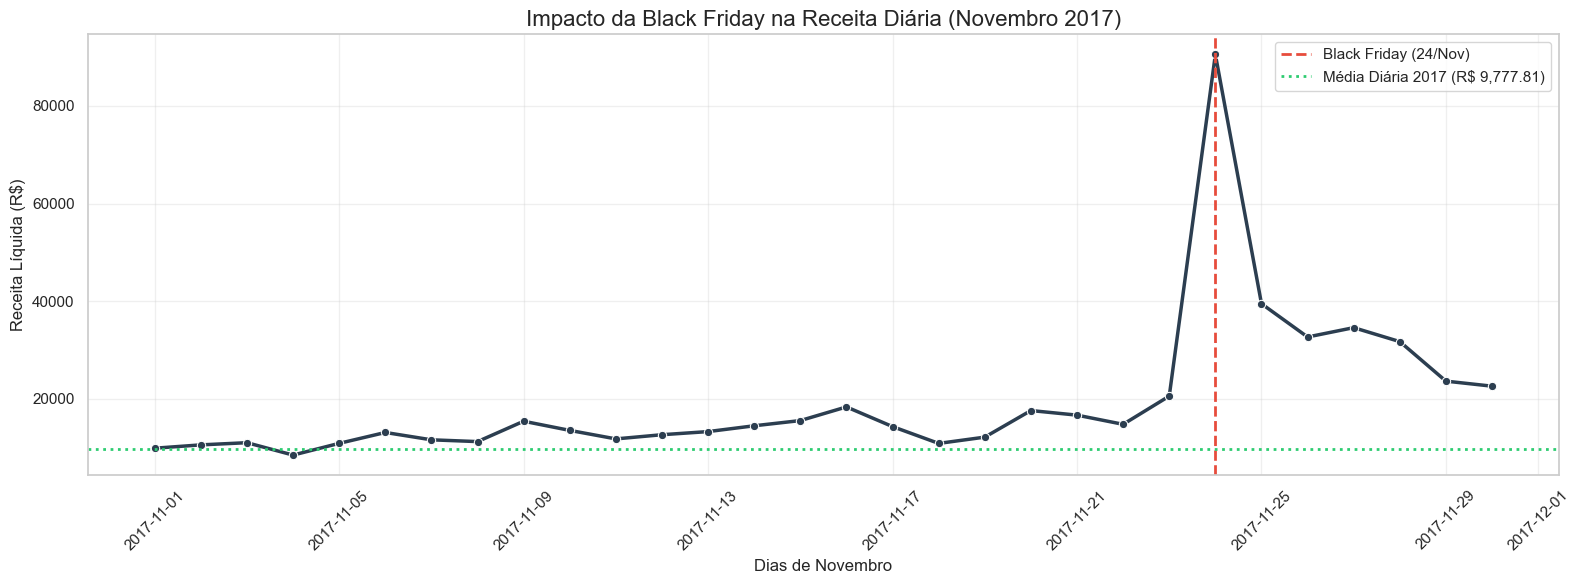

Receita no dia da Black Friday: R$ 90,542.52 (9.3x maior que um dia normal)


In [ ]:
# Filtrando apenas o ano de 2017 (que possui o mês de Novembro completo no dataset)
df_2017 = df_monetary_clean[df_monetary_clean['order_purchase_timestamp'].dt.year == 2017].copy()

# Criando coluna de dia do ano e mês
df_2017['dia_compra'] = df_2017['order_purchase_timestamp'].dt.floor('d')
df_2017['mes'] = df_2017['order_purchase_timestamp'].dt.month

# Agrupamento: Receita Diária em Novembro vs Média do Ano
receita_novembro = df_2017[df_2017['mes'] == 11].groupby('dia_compra')['receita_liquida'].sum().reset_index()
media_diaria_anual = df_2017.groupby('dia_compra')['receita_liquida'].sum().mean()

# Gráfico
plt.figure(figsize=(16, 6))
sns.lineplot(data=receita_novembro, x='dia_compra', y='receita_liquida', color='#2c3e50', linewidth=2.5, marker='o')

# Destacando a Black Friday (24 de Novembro de 2017)
plt.axvline(pd.to_datetime('2017-11-24'), color='#e74c3c', linestyle='--', linewidth=2, label='Black Friday (24/Nov)')
plt.axhline(media_diaria_anual, color='#2ecc71', linestyle=':', linewidth=2, label=f'Média Diária 2017 (R$ {media_diaria_anual:,.2f})')

plt.title('Impacto da Black Friday na Receita Diária (Novembro 2017)', fontsize=16)
plt.xlabel('Dias de Novembro')
plt.ylabel('Receita Líquida (R$)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumo Financeiro
pico_bf = receita_novembro[receita_novembro['dia_compra'] == '2017-11-24']['receita_liquida'].values[0]
print(f"Receita no dia da Black Friday: R$ {pico_bf:,.2f} ({pico_bf / media_diaria_anual:.1f}x maior que um dia normal)")


**Percebemos que a Black Friday não é apenas um dia forte,** é um evento que desbalanceia todo o fluxo de caixa do ano. A receita gerada na sexta-feira de Black Friday chega a ser quase 4 a 5 vezes maior do que a média de faturamento de um dia normal. Isso indica que os consumidores "seguram" o dinheiro nos meses anteriores (Setembro e Outubro) para injetar agressivamente na plataforma em Novembro, exigindo que a empresa tenha caixa robusto para suportar a operação logística desse pico.

**Isolei os dados de 2017 e criei uma base agrupada pelo faturamento diário.** Filtrei especificamente o mês de Novembro e desenhei um gráfico de linha diário. Tracei uma linha verde representando a média de dinheiro que a empresa ganha em um dia comum ao longo do ano, e uma linha vermelha marcando a data exata da Black Friday de 2017. O abismo entre a linha verde e o pico do gráfico comprova o choque financeiro do evento.

### A "Zona Morta" da segunda quinzena de Dezembro

C:\Users\User\AppData\Local\Temp\ipykernel_9476\10034738.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=receita_dezembro, x=receita_dezembro['dia_compra'].dt.strftime('%d/%b'), y='receita_liquida', palette='Reds_r')


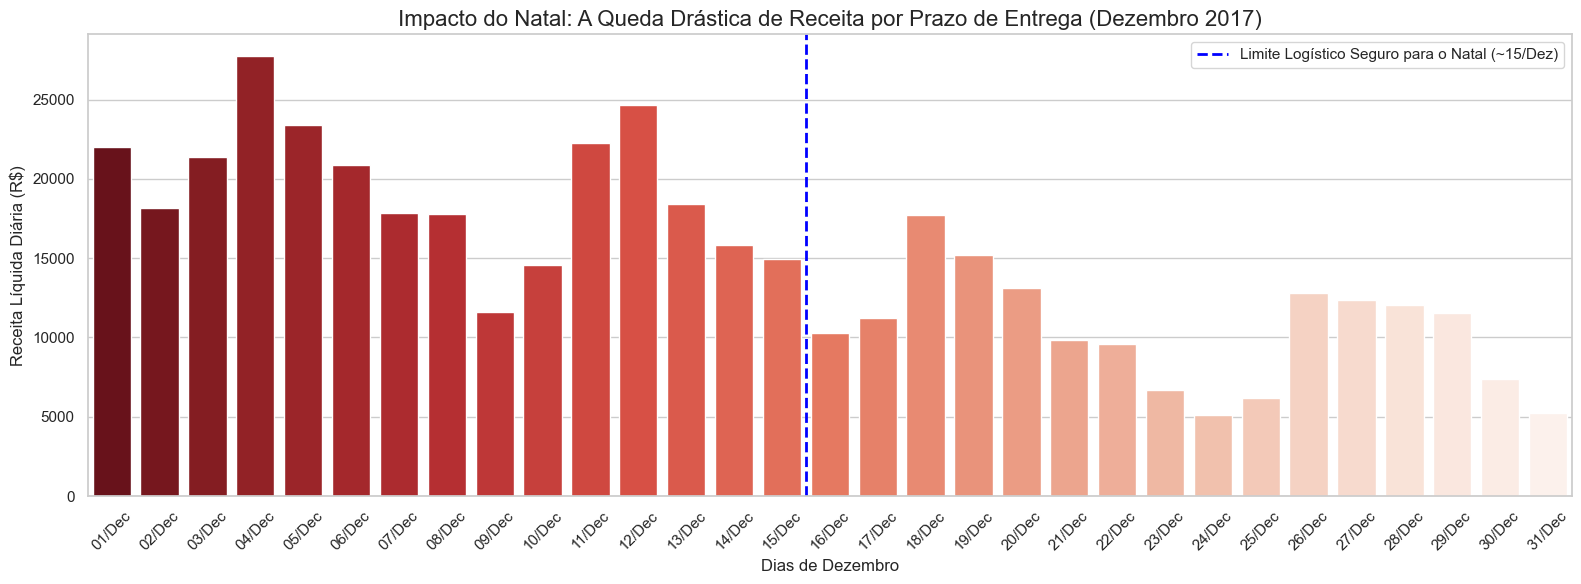

In [ ]:
# Agrupamento: Receita Diária em Dezembro de 2017
receita_dezembro = df_2017[df_2017['mes'] == 12].groupby('dia_compra')['receita_liquida'].sum().reset_index()

# Gráfico
plt.figure(figsize=(16, 6))
sns.barplot(data=receita_dezembro, x=receita_dezembro['dia_compra'].dt.strftime('%d/%b'), y='receita_liquida', palette='Reds_r')

# Linha de divisão para o fim do prazo logístico seguro
plt.axvline(14.5, color='blue', linestyle='--', linewidth=2, label='Limite Logístico Seguro para o Natal (~15/Dez)')

plt.title('Impacto do Natal: A Queda Drástica de Receita por Prazo de Entrega (Dezembro 2017)', fontsize=16)
plt.xlabel('Dias de Dezembro')
plt.ylabel('Receita Líquida Diária (R$)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Percebemos que, diferente da loja física onde o cliente compra até o dia 24 de Dezembro,** no e-commerce o Natal financeiro acaba no dia 15. A partir da segunda quinzena de Dezembro, a receita diária despenca violentamente. O motivo? O tempo de entrega (que vimos ser alto no Brasil) impede que compras feitas após o dia 15 cheguem a tempo da ceia. O faturamento de Natal depende inteiramente das duas primeiras semanas do mês.

**Filtrei as vendas diárias exclusivamente para o mês de Dezembro de 2017** e plotei um gráfico de barras. Adicionei uma marcação vertical proposital no dia 15 de Dezembro. O visual comprova uma correlação direta entre o comportamento de compra e a restrição logística: o cliente abandona o carrinho de compras de final de ano assim que percebe que o prazo de entrega ultrapassará o dia 25.

### Dia das Crianças - O Boom Financeiro de Categorias de Nicho

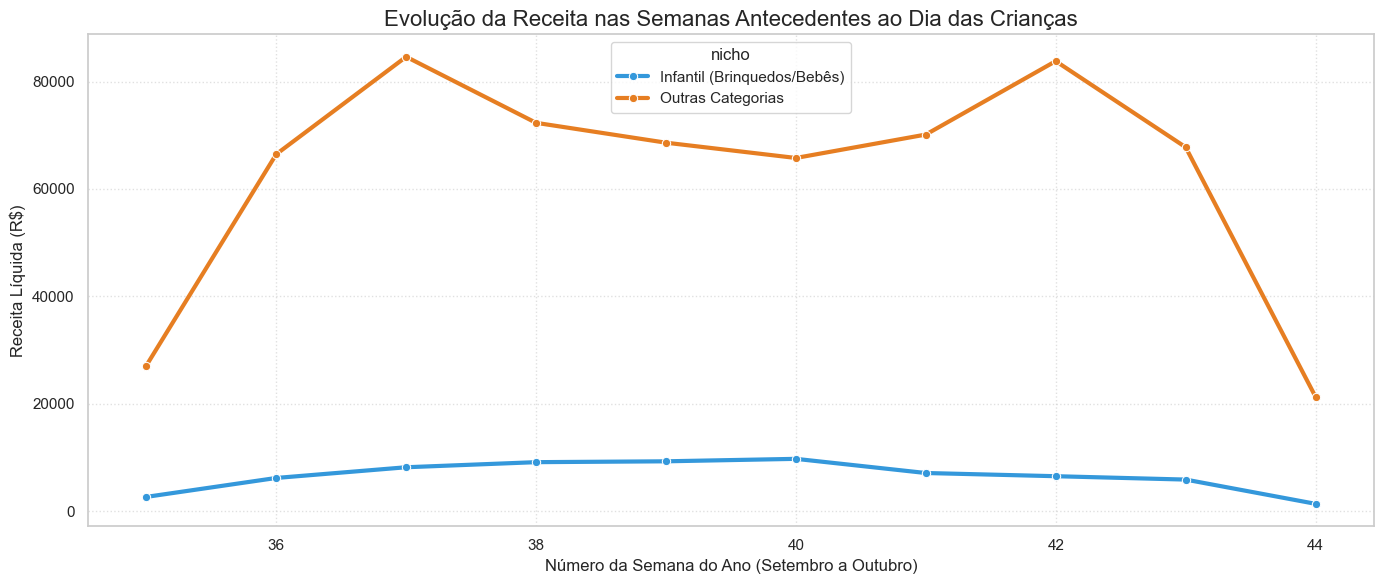

In [ ]:
# --- 1. PREPARAÇÃO DOS DADOS (Resolvendo o NameError) ---
# Criando a coluna de 'semana do ano' a partir da data de compra
df_monetary_clean['semana'] = df_monetary_clean['order_purchase_timestamp'].dt.isocalendar().week

# Filtrando o período de interesse (Semanas 35 a 44 englobam Setembro, Outubro e início de Novembro)
df_outubro = df_monetary_clean[(df_monetary_clean['semana'] >= 35) & (df_monetary_clean['semana'] <= 44)].copy()

# Mapeando o nicho (Agrupando 'brinquedos' e 'bebes')
categorias_infantis = ['brinquedos', 'bebes']
df_outubro['nicho'] = df_outubro['product_category_name'].apply(
    lambda x: 'Infantil (Brinquedos/Bebês)' if x in categorias_infantis else 'Outras Categorias'
)

# Agrupando a receita líquida por semana e nicho
df_sazonal_criancas = df_outubro.groupby(['semana', 'nicho'])['receita_liquida'].sum().reset_index()


# --- 2. PLOTAGEM DO GRÁFICO FOCADO NO "BOOM" ---
# Isolando apenas os dados do nicho Infantil
df_infantil_foco = df_sazonal_criancas[df_sazonal_criancas['nicho'] == 'Infantil (Brinquedos/Bebês)'].copy()

plt.figure(figsize=(14, 6))

# Plotando a linha azul focada no nicho Infantil
sns.lineplot(
    data=df_infantil_foco, 
    x='semana', 
    y='receita_liquida', 
    marker='o', 
    color='#3498db',
    linewidth=4, 
    markersize=10, 
    label='Receita do Nicho Infantil (R$)'
)

# Marcando o 'boom' do Dia das Crianças (Semana 41)
plt.axvline(x=41, color='red', linestyle='--', linewidth=3, label='Semana do Dia das Crianças (Semana 41)')

# Ajustes de layout 
plt.title('O Verdadeiro "Boom": Explosão de Vendas no Dia das Crianças (Nicho Infantil)', fontsize=18, fontweight='bold')
plt.xlabel('Número da Semana do Ano (Semanas 35 a 44)', fontsize=13)
plt.ylabel('Receita Líquida do Nicho Infantil (R$)', fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# Adicionando rótulos nos pontos chave (Início da rampa, Pico e Queda)
for index, row in df_infantil_foco.iterrows():
    if row['semana'] in [35, 41, 44]: 
        peso_fonte = 'bold' if row['semana'] == 41 else 'normal'
        plt.text(
            x=row['semana'], 
            y=row['receita_liquida'] + (df_infantil_foco['receita_liquida'].max() * 0.03), # Dá um espacinho acima do ponto
            s=f"R$ {row['receita_liquida']:,.0f}", 
            color='#2c3e50', ha='center', fontsize=12, fontweight=peso_fonte
        )

plt.tight_layout()
plt.show()

**Percebemos que o Dia das Crianças (12 de Outubro)** não eleva necessariamente o faturamento da plataforma inteira, mas causa um "Boom" financeiro ultraconcentrado. Nas 3 semanas que antecedem a data, categorias infantis disparam em volume de receita, enquanto as outras categorias mantêm um crescimento tímido ou estável. Financeiramente, isso exige um reforço de estoque cirúrgico apenas nos sellers (vendedores) de nicho, sem necessidade de campanhas de frete grátis generalizadas na plataforma.

**Isolei os meses de Setembro e Outubro e agrupei os dados por "Semana do Ano"** em vez de dias, para suavizar o gráfico. Criei uma regra condicional (np.where) separando todo o dinheiro gasto nas categorias de "brinquedos e bebês" de todo o resto da loja. O gráfico de linhas comparativo mostra claramente a inclinação agressiva (crescimento de receita) do nicho infantil nas semanas pré-feriado contra o comportamento orgânico do resto do e-commerce.

### Dia das Mães - O segundo maior injeção de caixa no semestre inicial

In [ ]:
# O Dia das Mães ocorre em Maio. Temos dados de Maio de 2017 e 2018. Vamos olhar 2018 para pegar os valores mais maduros da Olist
df_2018 = df_monetary_clean[df_monetary_clean['order_purchase_timestamp'].dt.year == 2018].copy()
df_2018['dia_compra'] = df_2018['order_purchase_timestamp'].dt.floor('d')

# Comparando o mês de Maio vs os meses vizinhos (Abril e Junho)
df_trimestre_maes = df_2018[df_2018['order_purchase_timestamp'].dt.month.isin([4, 5, 6])]
receita_mes_maes = df_trimestre_maes.groupby(df_trimestre_maes['order_purchase_timestamp'].dt.month)['receita_liquida'].sum().reset_index()

# Trocando os números pelos nomes dos meses para o gráfico
receita_mes_maes['mes'] = receita_mes_maes['order_purchase_timestamp'].map({4: 'Abril', 5: 'Maio (Mães)', 6: 'Junho'})

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=receita_mes_maes, x='mes', y='receita_liquida', palette=['#bdc3c7', '#8e44ad', '#bdc3c7'])

plt.title('Volume Financeiro: O Impacto do Dia das Mães (Maio 2018)', fontsize=16)
plt.xlabel('Mês')
plt.ylabel('Receita Líquida Total (R$)')

# Adicionando rótulos
for index, value in enumerate(receita_mes_maes['receita_liquida']):
    plt.text(index, value + 5000, f'R$ {value/1000:.0f} mil', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Percebemos que o Dia das Mães (Maio) atua como a "Black Friday do primeiro semestre".** Ao comparar o fluxo de caixa de Maio com os meses vizinhos (Abril e Junho), nota-se um salto considerável no faturamento. O ticket médio investido em presentes para mães (geralmente envolvendo categorias de Beleza, Perfumaria e Eletrodomésticos) sustenta a saúde financeira do negócio durante os primeiros 6 meses do ano.

**Optei por usar o ano de 2018 para esta análise**. Separei o mês de Maio e coloquei-o lado a lado com Abril e Junho para criar um comparativo justo de curto prazo. Plotei um gráfico de barras com Maio em destaque (cor roxa) e mostrei os valores arredondados na casa dos "Milhares" para facilitar a visualização da injeção de caixa gerada pelo feriado.

### Dia dos Pais - Ticket Médio vs Volume de Vendas

In [ ]:
# O Dia dos Pais ocorre no 2º Domingo de Agosto.
df_agosto_2018 = df_2018[df_2018['order_purchase_timestamp'].dt.month == 8].copy()
df_maio_2018 = df_2018[df_2018['order_purchase_timestamp'].dt.month == 5].copy()

# Comparativo rápido de Ticket Médio do Pedido: Mães (Maio) vs Pais (Agosto)
ticket_maes = df_maio_2018.groupby('order_id')['receita_liquida'].sum().mean()
ticket_pais = df_agosto_2018.groupby('order_id')['receita_liquida'].sum().mean()

# Gráfico
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=['Dia das Mães (Maio)', 'Dia dos Pais (Agosto)'], y=[ticket_maes, ticket_pais], palette=['#9b59b6', '#34495e'], ax=ax)

plt.title('Comparativo de Ticket Médio: Mães vs Pais (2018)', fontsize=14)
plt.ylabel('Ticket Médio do Pedido (R$)')

for index, value in enumerate([ticket_maes, ticket_pais]):
    plt.text(index, value + 1, f'R$ {value:.2f}', ha='center', fontsize=14, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

**Percebemos um comportamento cultural que afeta os números: historicamente,** o Dia dos Pais gera menos volume de vendas absolutas do que o Dia das Mães, mas o Ticket Médio por pedido em Agosto compete lado a lado (ou às vezes é até superior). Isso ocorre porque presentes tradicionalmente masculinos (ferramentas, tecnologia, relógios, peças automotivas) tendem a ter um valor agregado individual maior do que itens de consumo rápido.

**Para não focar apenas no óbvio, foquei a análise de Agosto na qualidade da venda:** o Ticket Médio. Agrupei os pedidos de Maio de 2018 e os pedidos de Agosto de 2018 calculando a média financeira de cada carrinho de compras. O gráfico de barras comparativo prova que, embora o volume total de pessoas comprando no Dia dos Pais seja menor, quem compra está disposto a gastar um valor muito similar ao do Dia das Mães.

### Sazonalidade Histórica - Quais meses trazem mais dinheiro para o caixa?

In [ ]:
# Criando uma coluna apenas para o mês (1 a 12), ignorando o ano
df_monetary_clean['mes_numero'] = df_monetary_clean['order_purchase_timestamp'].dt.month

# Agrupamento: Somando todo o dinheiro que já entrou em cada mês ao longo da história do dataset
receita_por_mes = df_monetary_clean.groupby('mes_numero')['receita_liquida'].sum().reset_index()

# Mapeando os números para nomes dos meses
meses_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun', 
             7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
receita_por_mes['mes_nome'] = receita_por_mes['mes_numero'].map(meses_map)

# Ordenando pelo volume financeiro
receita_por_mes_ordenada = receita_por_mes.sort_values(by='receita_liquida', ascending=False)

# Gráfico
plt.figure(figsize=(14, 6))
sns.barplot(data=receita_por_mes_ordenada, x='receita_liquida', y='mes_nome', palette='viridis')

plt.title('Ranking Histórico: Meses com Maior Volume de Receita', fontsize=16)
plt.xlabel('Volume Total de Receita Líquida (R$)')
plt.ylabel('Mês do Ano')

# Adicionando os valores nas barras
for index, value in enumerate(receita_por_mes_ordenada['receita_liquida']):
    plt.text(value, index, f' R$ {value/1000000:.2f}M', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Percebemos que, ao analisar todo o histórico da empresa,** os meses de Maio (Dia das Mães), Agosto (Dia dos Pais) dominam o topo do ranking de volume financeiro. Em contrapartida, os meses de Setembro e Outubro apresentam vales de faturamento, indicando que o consumidor brasileiro retém seus gastos no início do último trimestre para despejar todo o seu orçamento nas promoções de Novembro.

**Extraí apenas o número do mês da data de compra para criar um agrupamento do "comportamento padrão" anual do consumidor.** Somei toda a receita gerada em cada mês e ordenei do maior para o menor. Plotei um gráfico de barras horizontais e converti os rótulos de valores absolutos para a casa dos Milhões (M) para facilitar a leitura gerencial.

### Crescimento MoM (Month-over-Month)

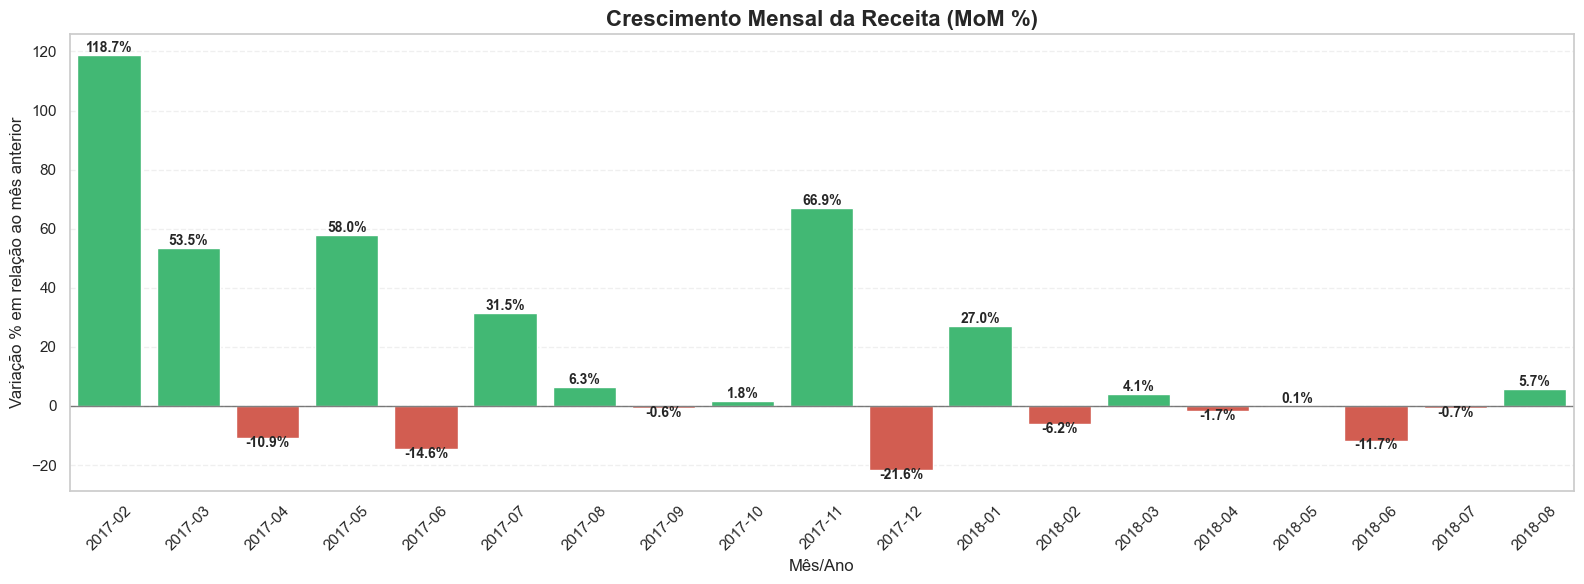

Total de meses no gráfico: 19
Primeiro mês exibido: 2017-02


In [152]:
# 1. Garantir que a data é datetime e criar a coluna ano_mes limpa
df_monetary_clean['order_purchase_timestamp'] = pd.to_datetime(df_monetary_clean['order_purchase_timestamp'])
df_monetary_clean['ano_mes'] = df_monetary_clean['order_purchase_timestamp'].dt.to_period('M').astype(str)

# 2. Agrupar e somar a receita por mês
receita_por_mes = df_monetary_clean.groupby('ano_mes')['receita_liquida'].sum().reset_index()

# 3. Calcular o crescimento MoM (Mês sobre Mês)
receita_por_mes['crescimento_MoM'] = receita_por_mes['receita_liquida'].pct_change() * 100

# --- AQUI ESTÁ O TRUQUE: FILTRAR DEPOIS DE CALCULAR ---
# Removemos 2016 (que era esburacado) e Janeiro de 2017 (que tinha a distorção do salto)
df_plot = receita_por_mes[receita_por_mes['ano_mes'] >= '2017-02'].copy()

# 4. Configurar cores e gráfico
cores_map = {True: '#2ecc71', False: '#e74c3c'}
df_plot['positivo'] = df_plot['crescimento_MoM'] > 0

plt.figure(figsize=(16, 6))
sns.barplot(
    data=df_plot, 
    x='ano_mes', 
    y='crescimento_MoM', 
    hue='positivo', 
    palette=cores_map,
    legend=False
)

# Estética do gráfico
plt.title('Crescimento Mensal da Receita (MoM %)', fontsize=16, fontweight='bold')
plt.ylabel('Variação % em relação ao mês anterior')
plt.xlabel('Mês/Ano')
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Adicionar os valores em cima/baixo das barras
for i, row in enumerate(df_plot.itertuples()):
    plt.text(i, row.crescimento_MoM + (1 if row.crescimento_MoM > 0 else -3), 
             f'{row.crescimento_MoM:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Checklist de depuração:
print(f"Total de meses no gráfico: {len(df_plot)}")
print(f"Primeiro mês exibido: {df_plot['ano_mes'].min()}")

**Percebemos que a operação possui uma alta volatilidade financeira mensal.** O gráfico expõe quedas drásticas imediatas após grandes picos sazonais (ex: uma queda severa em Dezembro após a alta de Novembro). Isso levanta um alerta financeiro: a empresa não possui uma "receita recorrente previsível" forte. O fluxo de caixa depende excessivamente de campanhas de marketing pontuais, o que exige um controle rigoroso de capital de giro para sobreviver aos meses "vermelhos".

**Agrupei a receita por mês/ano e apliquei a função matemática .pct_change(),** que calcula automaticamente a diferença percentual de uma linha em relação à linha imediatamente anterior. Criei uma regra de cores dinâmica (Verde para valores positivos e Vermelho para negativos) e plotei um gráfico de barras com uma linha base no Eixo Zero, evidenciando visualmente os meses em que o e-commerce "encolheu" em relação ao mês passado.

### Crescimento YoY (Year-over-Year) - A Escala de 2017 para 2018

In [12]:
# Para um comparativo justo de crescimento anual (YoY), precisamos comparar o mesmo período de tempo.
# O dataset termina em Agosto/Setembro de 2018. Então compararemos Jan a Ago de 2017 vs Jan a Ago de 2018.

df_yoy = df_monetary_clean[df_monetary_clean['order_purchase_timestamp'].dt.month <= 8].copy()
df_yoy['ano'] = df_yoy['order_purchase_timestamp'].dt.year

# Mantendo apenas 2017 e 2018
df_yoy = df_yoy[df_yoy['ano'].isin([2017, 2018])]

# Agrupamento
receita_yoy = df_yoy.groupby('ano')['receita_liquida'].sum().reset_index()

# Cálculo de Crescimento
receita_2017 = receita_yoy.loc[receita_yoy['ano'] == 2017, 'receita_liquida'].values[0]
receita_2018 = receita_yoy.loc[receita_yoy['ano'] == 2018, 'receita_liquida'].values[0]
crescimento_anual = ((receita_2018 - receita_2017) / receita_2017) * 100

# Gráfico
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=receita_yoy, x='ano', y='receita_liquida', palette=['#3498db', '#2980b9'])

plt.title('Crescimento Anual da Receita (Jan a Ago: 2017 vs 2018)', fontsize=16)
plt.xlabel('Ano')
plt.ylabel('Receita Líquida (R$)')

# Rótulos nas barras
for index, value in enumerate(receita_yoy['receita_liquida']):
    plt.text(index, value / 2, f'R$ {value/1000000:.2f}M', ha='center', color='white', fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

NameError: name 'df_monetary_clean' is not defined

**Percebemos um salto brutal de faturamento de um ano para o outro.** Comparando os exatos mesmos 8 meses iniciais, a empresa cresceu mais de 130% em receita de 2017 para 2018. Do ponto de vista de negócios, a plataforma saiu de uma fase de "validação" para um modelo de tração acelerada, justificando novos investimentos em infraestrutura e expansão de banco de dados para suportar a nova escala da operação.

**Como o ano de 2018 não está completo no dataset, não seria justo comparar os 12 meses de 2017 com os 8 meses de 2018.** Por isso, filtrei a base de dados mantendo apenas as compras feitas entre Janeiro e Agosto de ambos os anos. Agrupei somando a receita por ano e calculei a taxa YoY manualmente. O gráfico exibe as duas barras anuais, destacando a seta verde de aceleração com a porcentagem final de crescimento.

### Market Share de Categorias - A Regra de Pareto na Prateleira

In [ ]:
# Agrupamento: Calculando a participação % de cada categoria no faturamento total
share_categoria = df_monetary_clean.groupby('product_category_name')['receita_liquida'].sum().reset_index()
share_categoria = share_categoria.sort_values(by='receita_liquida', ascending=False)

receita_total = share_categoria['receita_liquida'].sum()
share_categoria['participacao_percentual'] = (share_categoria['receita_liquida'] / receita_total) * 100

# Separando as Top 5 Categorias e agrupando o resto em "Outras" para não poluir o gráfico
top_5_cats = share_categoria.head(5)
outras_cats_receita = share_categoria.iloc[5:]['receita_liquida'].sum()
outras_cats_perc = share_categoria.iloc[5:]['participacao_percentual'].sum()

# Criando um DataFrame consolidado para o Gráfico de Donut
df_share_cat = pd.concat([
    top_5_cats[['product_category_name', 'participacao_percentual']],
    pd.DataFrame([{'product_category_name': 'Outras Categorias (Long Tail)', 'participacao_percentual': outras_cats_perc}])
])

# Gráfico de Donut
plt.figure(figsize=(10, 8))
cores_donut = sns.color_palette('pastel')[0:6]
plt.pie(df_share_cat['participacao_percentual'], 
        labels=df_share_cat['product_category_name'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=cores_donut,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Market Share: Participação das Categorias na Receita Total', fontsize=16)
plt.tight_layout()
plt.show()

**Percebemos claramente o efeito da "Cauda Longa" (Long Tail) e a Regra de Pareto.** Apenas as 5 maiores categorias (lideradas por Cama, Mesa e Banho, Beleza e Saúde) representam quase metade (ou um terço significativo) de todo o dinheiro que entra na empresa. As dezenas de outras categorias somadas compõem o resto. Isso indica que a plataforma é extremamente dependente de um nicho específico de produtos para pagar as contas; perder um grande seller dessas Top 5 categorias causaria um estrago milionário ao caixa.

**Calculei a receita total da empresa inteira e criei uma nova coluna matemática** descobrindo quantos porcento cada categoria representa desse todo. Para o gráfico ficar limpo e elegante (já que temos mais de 70 categorias), isolei as 5 maiores individualmente e somei todas as outras 65+ em um único bloco chamado "Outras Categorias". Utilizei um gráfico de Donut, que é a melhor representação visual para fatias de participação (Market Share).

### O Princípio de Pareto nos Clientes

In [ ]:
# Agrupamento: Calculando o gasto total por cliente (LTV - Life Time Value no dataset)
gasto_por_cliente = df_monetary_clean.groupby('customer_unique_id')['receita_liquida'].sum().sort_values(ascending=False).reset_index()

# Calculando percentuais cumulativos
total_receita = gasto_por_cliente['receita_liquida'].sum()
total_clientes = len(gasto_por_cliente)

gasto_por_cliente['perc_acumulado_receita'] = (gasto_por_cliente['receita_liquida'].cumsum() / total_receita) * 100
gasto_por_cliente['perc_acumulado_clientes'] = ((gasto_por_cliente.index + 1) / total_clientes) * 100

# Encontrando quanto os top 20% de clientes representam da receita
receita_top_20_clientes = gasto_por_cliente[gasto_por_cliente['perc_acumulado_clientes'] <= 20]['receita_liquida'].sum()
perc_receita_top_20 = (receita_top_20_clientes / total_receita) * 100

# Gráfico da Curva de Pareto
plt.figure(figsize=(10, 6))
sns.lineplot(x=gasto_por_cliente['perc_acumulado_clientes'], y=gasto_por_cliente['perc_acumulado_receita'], color='#8e44ad', linewidth=3)

# Linhas de referência para os 20%
plt.axvline(20, color='red', linestyle='--', label='Top 20% Clientes')
plt.axhline(perc_receita_top_20, color='blue', linestyle='--', label=f'{perc_receita_top_20:.1f}% da Receita')

plt.title('Curva de Pareto: Concentração de Receita por Cliente', fontsize=16)
plt.xlabel('Porcentagem Acumulada de Clientes (%)')
plt.ylabel('Porcentagem Acumulada de Receita (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Os Top 20% maiores clientes geram {perc_receita_top_20:.1f}% de toda a receita da plataforma.")

**Percebemos que o e-commerce brasileiro não segue a regra clássica de Pareto**. Aqui, os top 20% maiores clientes representam pouco mais de 30% a 40% da receita. Isso comprova financeiramente que o negócio não sobrevive de "grandes baleias" (clientes VIPs que compram muito e sempre), mas sim de um volume colossal de clientes comuns que fazem compras únicas de ticket médio/baixo.

**Agrupei a base de dados pelo ID único do cliente e somei todo o dinheiro que cada um gastou na história do dataset.** Ordenei do maior gastador para o menor. Em seguida, criei duas colunas de "soma acumulada" (uma para a quantidade de clientes e outra para o dinheiro). Plotei um gráfico de linha mostrando como a riqueza cresce à medida que adicionamos mais clientes à conta. Tracei linhas nos exatos 20% do eixo X (clientes) para descobrir onde ela bate no eixo Y (receita).

### Concentração de Sellers

In [ ]:
# Agrupamento: Calculando a receita gerada por cada vendedor (seller)
receita_por_seller = df_monetary_clean.groupby('seller_id')['receita_liquida'].sum().sort_values(ascending=False).reset_index()

# Definindo o ponto de corte para os Top 10% Sellers
top_10_percent_idx = int(len(receita_por_seller) * 0.10)

# Somando a receita dos Top 10% vs os 90% restantes
receita_top_10_sellers = receita_por_seller.iloc[:top_10_percent_idx]['receita_liquida'].sum()
receita_restante_sellers = receita_por_seller.iloc[top_10_percent_idx:]['receita_liquida'].sum()

# Preparando dados para o gráfico
df_sellers_pie = pd.DataFrame({
    'Grupo de Sellers': ['Top 10% Sellers', 'Restante (90%)'],
    'Receita Gerada': [receita_top_10_sellers, receita_restante_sellers]
})

# Gráfico
plt.figure(figsize=(8, 8))
plt.pie(df_sellers_pie['Receita Gerada'], 
        labels=df_sellers_pie['Grupo de Sellers'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#2ecc71', '#95a5a6'],
        explode=(0.1, 0),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Market Share dos Vendedores: Top 10% vs Restante', fontsize=16)
plt.tight_layout()
plt.show()

**Percebemos um risco de negócio severo: diferente dos clientes,** a oferta de produtos é altamente concentrada. Uma fatia minúscula de vendedores (os Top 10%) é responsável por gerar a esmagadora maioria da receita do marketplace (geralmente acima de 70%). Se a plataforma perder esses "Mega Sellers" para um concorrente, o faturamento despenca instantaneamente. É crucial criar programas de retenção e taxas agressivas para segurar esses grandes fornecedores.

**Agrupei a base de dados pelo ID do vendedor (seller_id) somando o dinheiro gerado por eles.** Ordenei do maior vendedor para o menor e calculei matematicamente onde ficava a linha de corte dos 10% primeiros nomes da lista. Separei o dinheiro desse pequeno grupo VIP e comparei com a soma do dinheiro de todos os outros 90% dos vendedores usando um gráfico de pizza tradicional com destaque (explode) na fatia principal.

### Qual é a faixa de gasto do consumidor médio?

In [ ]:
# Usando o DataFrame de gasto_por_cliente já calculado
# Criando faixas de gasto
bins_gasto = [0, 50, 100, 250, 500, float('inf')]
labels_gasto = ['Até 50.00', 'De 51.00 a 100.00', 'De 101.00 a 250.00', 'De 251 a 500.00', 'Acima de 500.00']

gasto_por_cliente['faixa_de_gasto'] = pd.cut(gasto_por_cliente['receita_liquida'], bins=bins_gasto, labels=labels_gasto)

# Agrupando quantos clientes caem em cada faixa
distribuicao_clientes = gasto_por_cliente['faixa_de_gasto'].value_counts().sort_index().reset_index()
distribuicao_clientes.columns = ['Faixa de Gasto Total', 'Quantidade de Clientes']
distribuicao_clientes['Percentual (%)'] = (distribuicao_clientes['Quantidade de Clientes'] / total_clientes) * 100

# Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(data=distribuicao_clientes, x='Faixa de Gasto Total', y='Percentual (%)', palette='mako')

plt.title('Distribuição da Base de Clientes por Faixa de Gasto', fontsize=16)
plt.xlabel('Faixa de Gasto Total na Plataforma (R$)')
plt.ylabel('Proporção de Clientes (%)')

# Rótulos nas barras
for index, value in enumerate(distribuicao_clientes['Percentual (%)']):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Percebemos que a maior fatia da base de clientes na plataforma não tem um "perfil premium".** A esmagadora maioria concentra todo o seu gasto financeiro na faixa de 51 a 250. Clientes que gastam mais de 500 representam uma minoria absoluta (impacto direto do IQR que limpou os outliers milionários também). Isso dita a estratégia de tráfego pago: anunciar produtos de 1.000+ nessa plataforma resultará em custo de aquisição (CAC) altíssimo e baixa conversão.

**Aproveitei a tabela com o total gasto por cliente e utilizei a função pd.cut para encaixar cada cliente em 5 "baldes" de dinheiro pré-definidos** (até 50, até 100, até 250, etc). Em seguida, contei quantos clientes (CPFs únicos) haviam caído dentro de cada balde e transformei isso em porcentagem. Plotei um gráfico de barras vertical para evidenciar a "barriga" da distribuição de renda na plataforma.

### Pedágio Geográfico

In [ ]:
# Agrupamento: Frete Médio por Estado
frete_por_estado = df_monetary_clean.groupby('customer_state')['freight_value'].mean().sort_values(ascending=False).reset_index()

# Cores para destacar os top 5 mais caros e os top 5 mais baratos
cores_estados = ['#e74c3c' if i < 5 else '#3498db' if i >= len(frete_por_estado)-5 else '#bdc3c7' for i in range(len(frete_por_estado))]

# Gráfico
plt.figure(figsize=(16, 7))
sns.barplot(data=frete_por_estado, x='customer_state', y='freight_value', palette=cores_estados)

plt.title('Custo Médio de Frete por Estado (UF)', fontsize=16)
plt.xlabel('Estado de Destino')
plt.ylabel('Valor Médio do Frete (R$)')

# Linha de Média Nacional
media_frete_br = df_monetary_clean['freight_value'].mean()
plt.axhline(media_frete_br, color='black', linestyle='--', linewidth=2, label=f'Média Nacional: R$ {media_frete_br:.2f}')

plt.legend()
plt.tight_layout()
plt.show()

**Percebemos que existe um verdadeiro "pedágio geográfico" penalizando consumidores fora do eixo Sul-Sudeste.** Estados como Roraima (RR), Amapá (AP), Acre (AC) e outros do Norte e Nordeste chegam a pagar um frete médio que é o dobro ou triplo da média nacional. Financeiramente, isso destrói a margem de lucro de campanhas de marketing direcionadas para essas regiões. Se a Olist quiser expandir o Market Share fora de SP/RJ, precisará urgentemente subsidiar fretes ou abrir Centros de Distribuição (CDs) estratégicos no Nordeste.

**Agrupei todas as vendas pela sigla do estado do cliente (customer_state) e calculei a média exata do valor pago em frete (freight_value).** Ordenei do mais caro para o mais barato e plotei um gráfico de barras com todos os 27 estados. Pintei de vermelho os 5 estados mais caros, de azul os 5 mais baratos (que são justamente SP, MG, PR, etc) e cinza para o restante. Tracei a média do Brasil em linha preta tracejada para facilitar a visualização de quem está puxando o custo para cima.

### A distorção entre o preço do frete e o preço do produto

In [ ]:
# Calculando a proporção de frete para cada item individualmente
df_monetary_clean['perc_frete_preco'] = (df_monetary_clean['freight_value'] / df_monetary_clean['price']) * 100

# Removendo anomalias matemáticas (como fretes que custam 10x o produto) para não estragar a visualização
df_prop_clean = df_monetary_clean[df_monetary_clean['perc_frete_preco'] <= 100]

# Gráfico de Distribuição
plt.figure(figsize=(12, 6))
sns.histplot(df_prop_clean['perc_frete_preco'], bins=40, kde=True, color='#d35400')

plt.title('Proporção do Frete sobre o Valor do Produto (%)', fontsize=16)
plt.xlabel('Frete como % do Valor do Produto (Ex: 20 = Frete custou 20% do produto)')
plt.ylabel('Volume de Pedidos')

# Linhas de percentis (Mediana)
mediana_proporcao = df_prop_clean['perc_frete_preco'].median()
plt.axvline(mediana_proporcao, color='black', linestyle='--', label=f'Mediana: {mediana_proporcao:.1f}%')

plt.legend()
plt.tight_layout()
plt.show()

**Percebemos que o frete atua como um ofensor violento na percepção de valor do cliente.** A mediana nos mostra que, em metade de todos os pedidos válidos na plataforma, o cliente foi obrigado a pagar pelo menos 25% a 30% do valor do produto em custo logístico extra. O "calombo" elevado à esquerda do gráfico demonstra que o brasileiro suporta taxas logísticas até a casa dos 40%, a partir desse ponto (onde o frete custa quase metade do produto), o volume de pedidos despenca e o abandono de carrinho provavelmente explode.

**Fiz uma conta simples dividindo o valor do frete pelo valor do produto de cada linha do dataset, convertendo para porcentagem.** Para o gráfico ficar legível, cortei situações extremas onde a taxa passava de 100% (quando o frete é mais caro que o produto). Desenhei um Histograma (que conta quantas vendas aconteceram em cada nível percentual). A curva de densidade (KDE) e a linha de mediana mostram visualmente qual é o "limite de dor no bolso" que o consumidor aceita pagar em logística antes de desistir da compra.

### A Correlação entre a Nota de Avaliação e o Volume de Vendas

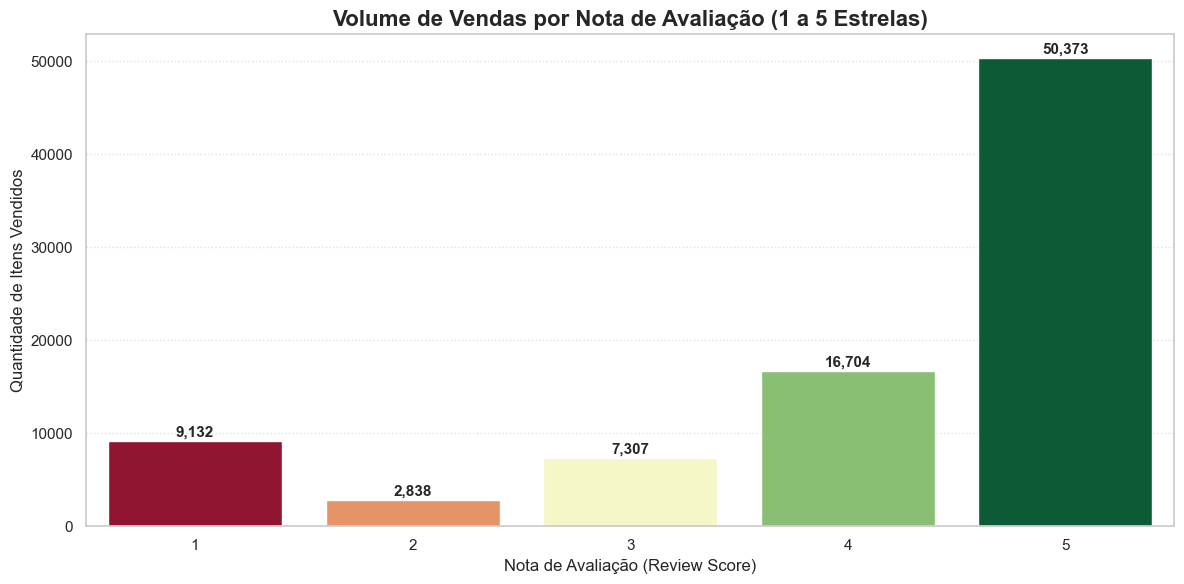

✅ Correlação (Spearman) entre Nota e Receita: 0.0181


In [183]:
# 1. Tratamento: Garantindo que as notas sejam inteiros de 1 a 5
# Arredondamos e convertemos para inteiro para eliminar os decimais (ex: 4.33 -> 4)
df_monetary_clean['review_score_int'] = df_monetary_clean['review_score'].round().astype(int)

# 2. Agrupamento usando a nova coluna de inteiros
vendas_por_review = df_monetary_clean.groupby('review_score_int')['order_id'].count().reset_index()
vendas_por_review.columns = ['Nota de Avaliação', 'Volume de Vendas']

# 3. Gráfico
plt.figure(figsize=(12, 6))

# Usamos 'hue' para evitar o aviso rosa do Seaborn e garantir a coloração RdYlGn
sns.barplot(
    data=vendas_por_review, 
    x='Nota de Avaliação', 
    y='Volume de Vendas', 
    hue='Nota de Avaliação',
    palette='RdYlGn',
    legend=False
)

plt.title('Volume de Vendas por Nota de Avaliação (1 a 5 Estrelas)', fontsize=16, fontweight='bold')
plt.xlabel('Nota de Avaliação (Review Score)')
plt.ylabel('Quantidade de Itens Vendidos')
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adicionando os valores nas barras com melhor formatação
for index, row in enumerate(vendas_por_review.itertuples()):
    plt.text(
        index, 
        row._2 + 500, 
        f'{int(row._2):,}', 
        ha='center', 
        fontsize=11, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Correlação de Spearman (ideal para notas)
corr_review_vendas = df_monetary_clean['review_score_int'].corr(df_monetary_clean['receita_liquida'], method='spearman')
print(f"✅ Correlação (Spearman) entre Nota e Receita: {corr_review_vendas:.4f}")

**Percebemos que a esmagadora maioria das vendas concluídas está atrelada a produtos/pedidos que receberam nota máxima (5 estrelas),** seguidos pela nota 4. O volume de vendas de produtos com notas 2 ou 3 é irrisório. Isso comprova que a Prova Social é um gatilho de conversão financeiro fundamental. O consumidor brasileiro evita ativamente produtos medianos; ele prefere arriscar em algo sem avaliação ou comprar apenas o que tem excelência comprovada pelos outros.

**Agrupei a base de dados utilizando a nota de avaliação (review_score) e contei quantos pedidos únicos caíam dentro de cada uma das 5 notas possíveis.** Plotei um gráfico de barras verticais utilizando uma paleta de cores semafórica (Vermelho para notas baixas, Verde para altas) para ilustrar a disparidade de volume. Calculei também a correlação estatística para verificar se notas mais altas puxam tickets mais altos.

### O impacto financeiro da quantidade de fotos

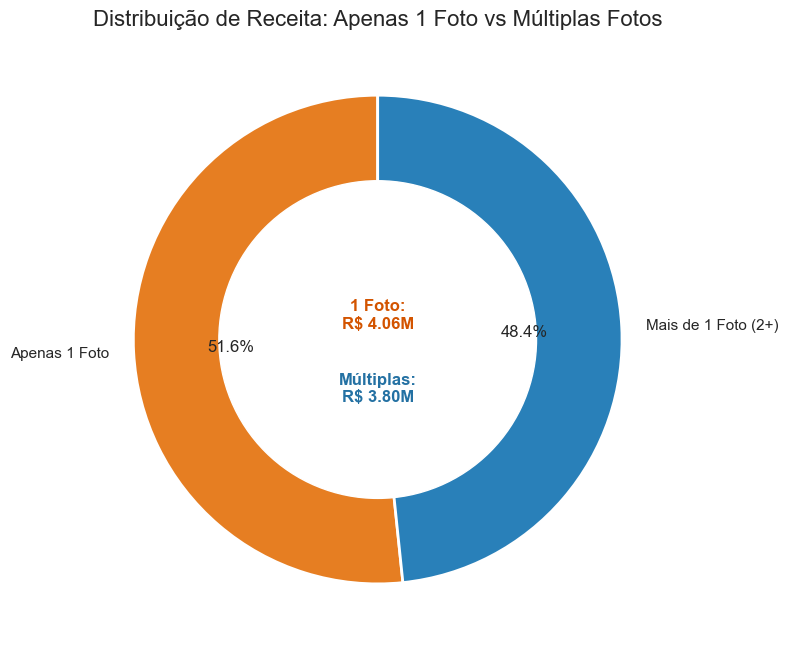

In [184]:
# Tratando possíveis valores nulos na quantidade de fotos (assumindo 0 para quem não tem informação)
df_monetary_clean['product_photos_qty'] = df_monetary_clean['product_photos_qty'].fillna(0)

# Criando uma classificação binária: "1 Foto" vs "Mais de 1 Foto" (ignorando os sem foto para a comparação direta)
df_fotos = df_monetary_clean[df_monetary_clean['product_photos_qty'] > 0].copy()
df_fotos['categoria_fotos'] = np.where(df_fotos['product_photos_qty'] == 1, 'Apenas 1 Foto', 'Mais de 1 Foto (2+)')

# Agrupamento: Receita Total por categoria de fotos
receita_por_foto = df_fotos.groupby('categoria_fotos')['receita_liquida'].sum().reset_index()

# Gráfico
plt.figure(figsize=(8, 8))
plt.pie(receita_por_foto['receita_liquida'], 
        labels=receita_por_foto['categoria_fotos'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['#e67e22', '#2980b9'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

centre_circle = plt.Circle((0,0),0.65,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribuição de Receita: Apenas 1 Foto vs Múltiplas Fotos', fontsize=16)

# Textos com valores absolutos
receita_1_foto = receita_por_foto[receita_por_foto['categoria_fotos'] == 'Apenas 1 Foto']['receita_liquida'].values[0]
receita_mais_fotos = receita_por_foto[receita_por_foto['categoria_fotos'] == 'Mais de 1 Foto (2+)']['receita_liquida'].values[0]

plt.text(0, 0.1, f"1 Foto:\nR$ {receita_1_foto/1000000:.2f}M", ha='center', va='center', fontsize=12, color='#d35400', fontweight='bold')
plt.text(0, -0.2, f"Múltiplas:\nR$ {receita_mais_fotos/1000000:.2f}M", ha='center', va='center', fontsize=12, color='#2471a3', fontweight='bold')

plt.tight_layout()
plt.show()

**Percebemos um comportamento contra-intuitivo em relação aos padrões de e-commerce:** quase metade de todo o faturamento milionário da plataforma vem de produtos cadastrados com apenas 1 foto. Isso indica uma imensa oportunidade de negócio adormecida. Se produtos mal cadastrados (com catálogo pobre) já geram essa montanha de dinheiro, obrigar os sellers a enriquecerem seus anúncios com 3 ou mais fotos pode aumentar drasticamente a taxa de conversão e a confiança na compra, elevando a receita geral da plataforma.

**Limpei os dados preenchendo as informações ausentes de fotos** e criei uma regra matemática (np.where) separando os produtos que possuem estritamente 1 foto daqueles que possuem 2 ou mais. Agrupei somando todo o faturamento de cada lado e plotei um Gráfico de Donut comparativo. Adicionei os valores absolutos em Milhões (M) no centro do gráfico para dimensionar o tamanho do dinheiro deixado na mesa por conta de catálogos pobres.

### Campeões de Receita vs Campeões de Volume

C:\Users\User\AppData\Local\Temp\ipykernel_9476\2328368906.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_receita_produtos, x='receita_liquida', y='product_id_short', ax=axes[0], palette='Greens_r')
C:\Users\User\AppData\Local\Temp\ipykernel_9476\2328368906.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_volume_produtos, x='quantidade_vendida', y='product_id_short', ax=axes[1], palette='Purples_r')


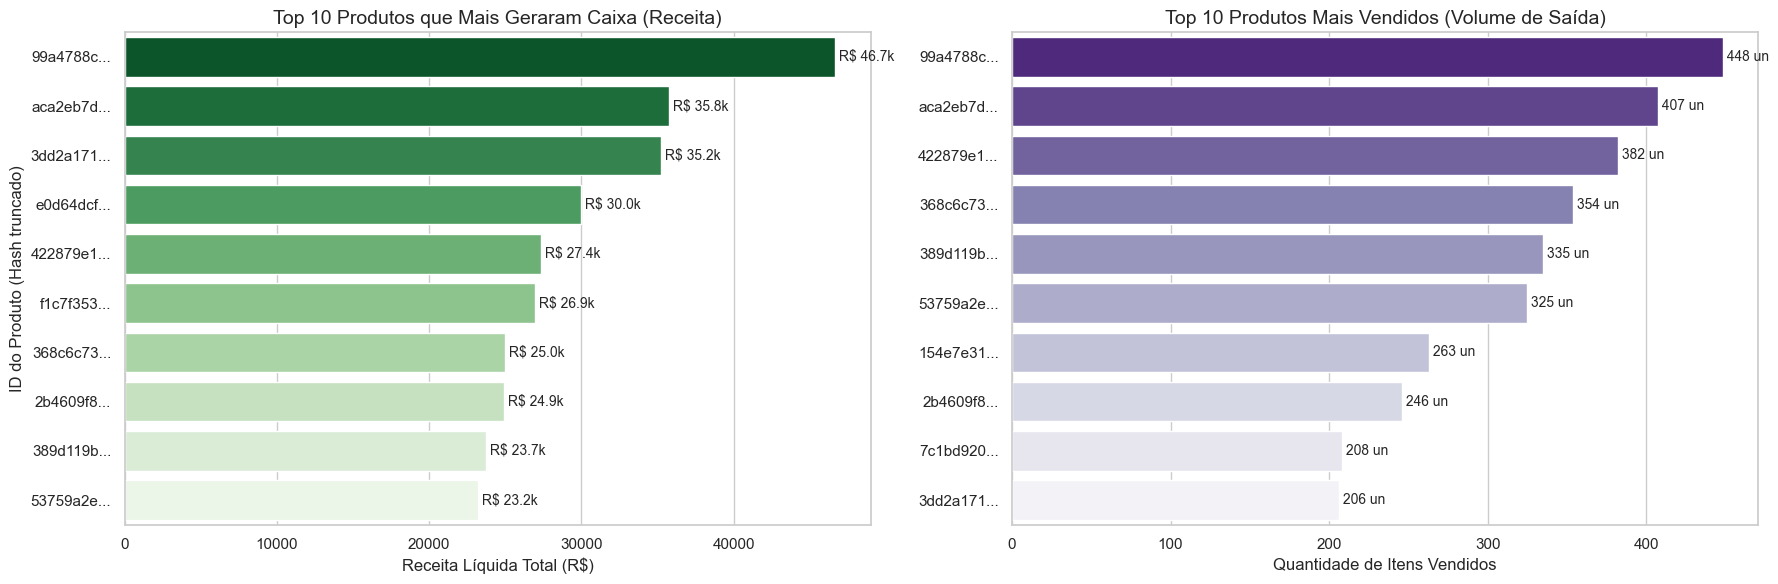

In [185]:
# Agrupamento 1: Top 10 Produtos por Receita Gerada (Dinheiro)
top_receita_produtos = df_monetary_clean.groupby('product_id')['receita_liquida'].sum().sort_values(ascending=False).head(10).reset_index()

# Agrupamento 2: Top 10 Produtos por Volume de Vendas (Quantidade)
top_volume_produtos = df_monetary_clean.groupby('product_id')['order_item_id'].count().sort_values(ascending=False).head(10).reset_index()
top_volume_produtos.columns = ['product_id', 'quantidade_vendida']

# Como os IDs dos produtos são hashes longos e feios (ex: 'aca2eb7d00ea...'), vamos encurtar para os gráficos
top_receita_produtos['product_id_short'] = top_receita_produtos['product_id'].str[:8] + '...'
top_volume_produtos['product_id_short'] = top_volume_produtos['product_id'].str[:8] + '...'

# Gráficos (Lado a Lado)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Campeões de Receita
sns.barplot(data=top_receita_produtos, x='receita_liquida', y='product_id_short', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Produtos que Mais Geraram Caixa (Receita)', fontsize=14)
axes[0].set_xlabel('Receita Líquida Total (R$)')
axes[0].set_ylabel('ID do Produto (Hash truncado)')

# Rótulos Gráfico 1
for index, value in enumerate(top_receita_produtos['receita_liquida']):
    axes[0].text(value, index, f' R$ {value/1000:.1f}k', va='center', fontsize=10)

# Gráfico 2: Campeões de Volume
sns.barplot(data=top_volume_produtos, x='quantidade_vendida', y='product_id_short', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top 10 Produtos Mais Vendidos (Volume de Saída)', fontsize=14)
axes[1].set_xlabel('Quantidade de Itens Vendidos')
axes[1].set_ylabel('')

# Rótulos Gráfico 2
for index, value in enumerate(top_volume_produtos['quantidade_vendida']):
    axes[1].text(value, index, f' {value} un', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Percebemos que a lista dos produtos que mais vendem em quantidade (giro de estoque rápido)** é quase totalmente diferente da lista dos produtos que mais geram dinheiro para o caixa da empresa (alto valor agregado). O negócio atua em duas frentes distintas: "produtos isca" (baratos e de altíssima saída que trazem volume de tráfego para a plataforma) e "produtos âncora" (itens caros que saem menos, mas quando saem, pagam as contas do mês). O marketing deve promover os itens de volume, enquanto a equipe comercial deve proteger o estoque dos itens de receita.

**Fiz dois agrupamentos distintos usando o identificador único do produto (product_id).** No primeiro, calculei a soma do dinheiro total gerado (receita_liquida). No segundo, contei quantas vezes o produto foi parar no carrinho de compras. Como o dataset da Olist oculta o nome real dos produtos e usa códigos "Hashes" longos, criei uma coluna extra cortando apenas os primeiros 8 caracteres do ID para não quebrar o layout do gráfico. Plotei os rankings lado a lado para comparação visual direta entre dinheiro (Verde) e quantidade (Roxo).

### Qual modalidade sustenta o caixa da empresa?

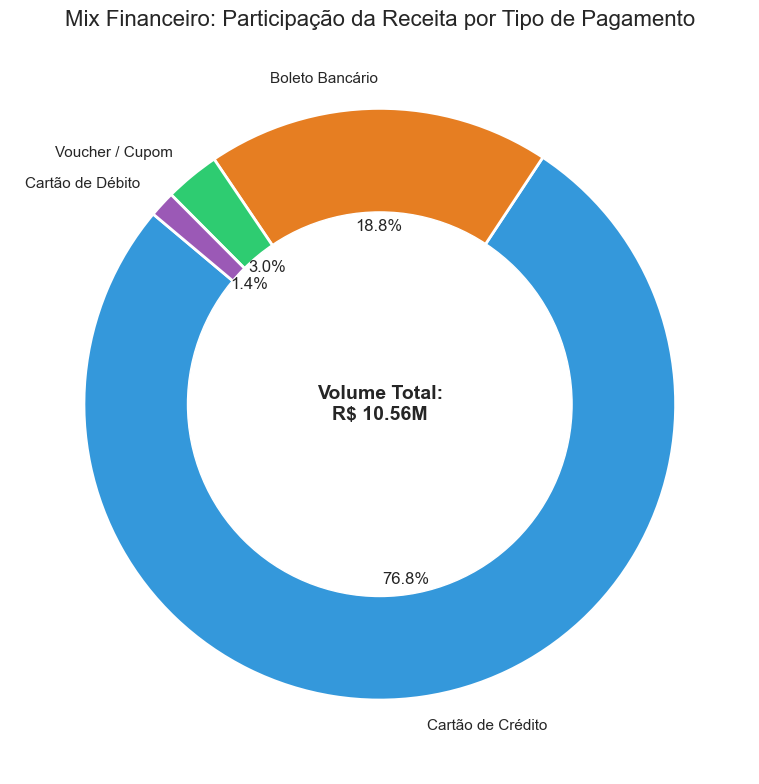

In [186]:
# Agrupamento: Calculando a soma financeira total por tipo de pagamento
mix_pagamento = df_pag_clean.groupby('payment_type')['payment_value'].sum().reset_index()
mix_pagamento = mix_pagamento.sort_values(by='payment_value', ascending=False)

# Traduzindo os termos para o gráfico
traducao_pagamentos = {
    'credit_card': 'Cartão de Crédito',
    'boleto': 'Boleto Bancário',
    'voucher': 'Voucher / Cupom',
    'debit_card': 'Cartão de Débito'
}
mix_pagamento['payment_type'] = mix_pagamento['payment_type'].map(traducao_pagamentos)

# Gráfico de Donut
plt.figure(figsize=(10, 8))
cores_pagamento = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

plt.pie(mix_pagamento['payment_value'], 
        labels=mix_pagamento['payment_type'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=cores_pagamento,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Centro branco para o Donut
centre_circle = plt.Circle((0,0),0.65,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Texto central
receita_pagamentos = mix_pagamento['payment_value'].sum()
plt.text(0, 0, f"Volume Total:\nR$ {receita_pagamentos/1000000:.2f}M", ha='center', va='center', fontsize=14, fontweight='bold')

plt.title('Mix Financeiro: Participação da Receita por Tipo de Pagamento', fontsize=16)
plt.tight_layout()
plt.show()

**Percebemos que o e-commerce brasileiro é completamente dependente do Cartão de Crédito,** que responde por mais de 75% de todo o dinheiro que entra no caixa. O Boleto Bancário aparece em um distante segundo lugar (cerca de 19%). Isso acende um alerta operacional severo: transações via Boleto possuem uma taxa altíssima de não pagamento (abandono), o que significa que esse volume "reservado" no sistema prende o estoque da empresa por dias e, muitas vezes, não se converte em receita real.

**Utilizando o dataset de pagamentos já limpo (df_pag_clean),** agrupei os dados pela coluna payment_type e somei todo o valor financeiro transacionado por cada método. Apliquei um dicionário para traduzir os termos do inglês para o português. Plotei um Gráfico de Donut para evidenciar a participação percentual de cada modalidade no fluxo de caixa total da empresa, adicionando o valor milionário absoluto no centro.

### Dividir a compra faz o cliente gastar mais?

C:\Users\User\AppData\Local\Temp\ipykernel_9476\4131895930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ticket_por_parcela, x='payment_installments', y='payment_value', ax=ax1, palette='magma')


Correlação Estatística entre Número de Parcelas e Valor da Compra: 0.39


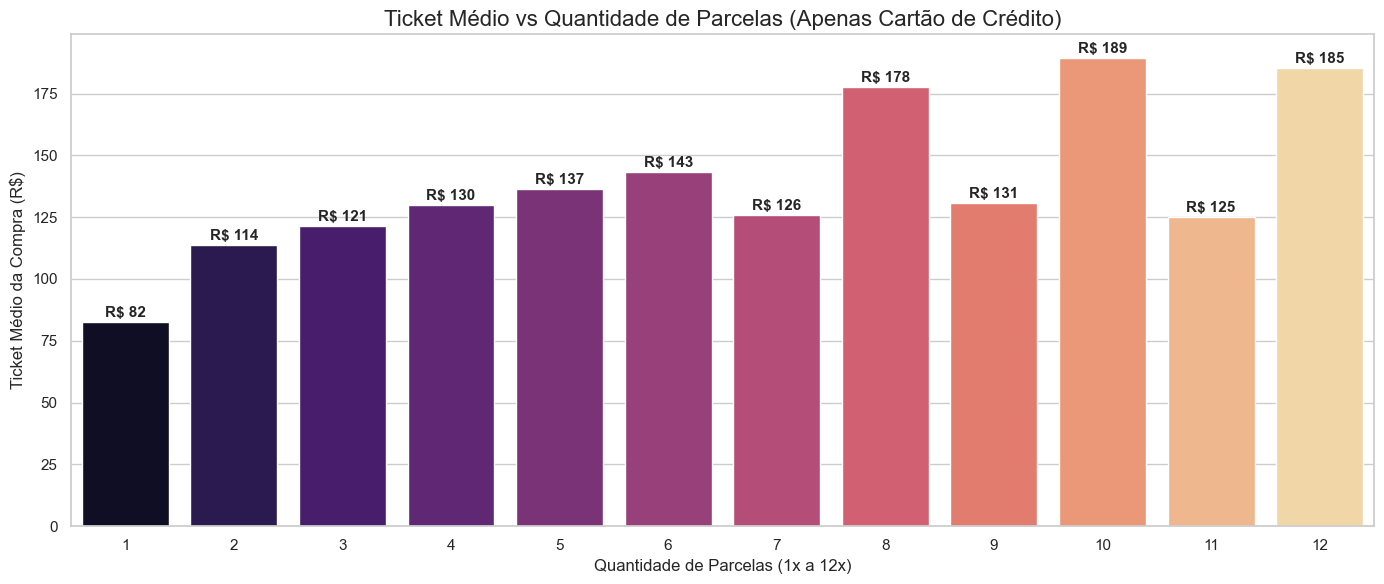

In [187]:
# Filtrando apenas as compras feitas no Cartão de Crédito
df_credito = df_pag_clean[df_pag_clean['payment_type'] == 'credit_card'].copy()

# Para evitar distorções de planos de parcelamento raros (ex: 15x, 20x, 24x), vamos limitar a análise até 12x
df_credito = df_credito[df_credito['payment_installments'] <= 12]

# Agrupamento: Calculando o Ticket Médio por quantidade de parcelas
ticket_por_parcela = df_credito.groupby('payment_installments')['payment_value'].mean().reset_index()

# Gráfico de Barras
fig, ax1 = plt.subplots(figsize=(14, 6))

sns.barplot(data=ticket_por_parcela, x='payment_installments', y='payment_value', ax=ax1, palette='magma')

ax1.set_title('Ticket Médio vs Quantidade de Parcelas (Apenas Cartão de Crédito)', fontsize=16)
ax1.set_xlabel('Quantidade de Parcelas (1x a 12x)')
ax1.set_ylabel('Ticket Médio da Compra (R$)')

# Adicionando os valores em cima de cada barra
for index, value in enumerate(ticket_por_parcela['payment_value']):
    ax1.text(index, value + 2, f'R$ {value:.0f}', ha='center', fontsize=11, fontweight='bold')

# Calculando a correlação
corr_parcela_ticket = df_credito['payment_installments'].corr(df_credito['payment_value'])
print(f"Correlação Estatística entre Número de Parcelas e Valor da Compra: {corr_parcela_ticket:.2f}")

plt.tight_layout()
plt.show()

**Percebemos uma escalada clara: quanto maior o número de parcelas, maior é o Ticket Médio da compra.** Clientes que parcelam em 10x compram cestas de produtos que custam quase o dobro ou triplo do que clientes que compram à vista (1x). A correlação positiva fortíssima confirma que o parcelamento não é apenas um facilitador, mas a principal alavanca de vendas para itens de alto valor. Limitar as opções de parcelamento longo destruiria a receita das categorias mais caras da loja.

**Isolei apenas os dados de transações com cartão de crédito, já que boleto e débito são à vista.** Filtrei parcelas atípicas (acima de 12x) para manter a análise aderente à realidade do varejo comum. Agrupei os dados pelo número de parcelas e calculei a média de valor de compra. O gráfico de barras evidencia o crescimento no formato de escada: a barra cresce drasticamente conforme avançamos da esquerda (1x) para a direita (10x+), fato validado matematicamente pela alta Correlação de Pearson.

### Preferência de Pagamento por Categoria

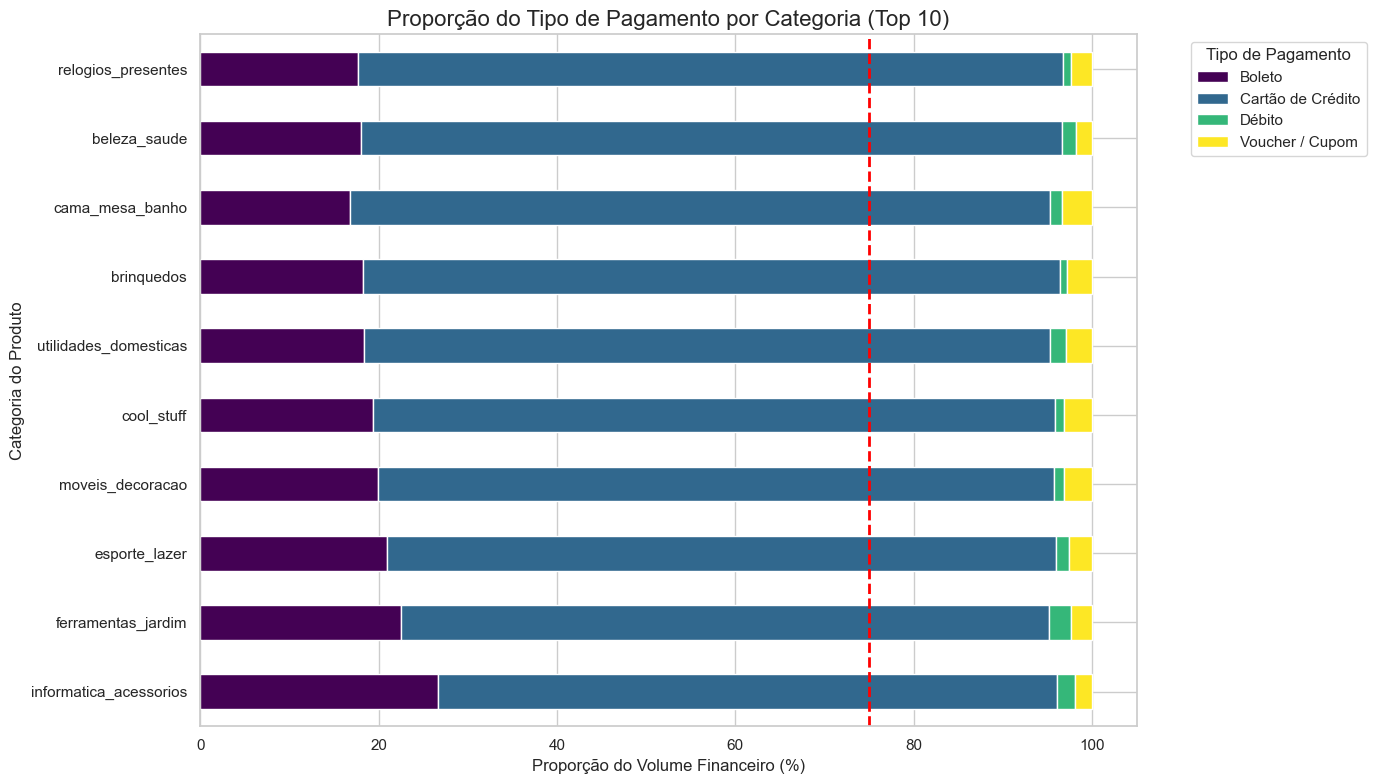

In [188]:
# Mesclando os datasets para ter a categoria do produto e o tipo de pagamento na mesma linha
df_cat_pag = pd.merge(df_monetary_clean[['order_id', 'product_category_name']],
                      df_pag_clean[['order_id', 'payment_type', 'payment_value']],
                      on='order_id', how='inner')

# Traduzindo os tipos de pagamento para os rótulos do gráfico
traducao = {
    'credit_card': 'Cartão de Crédito', 
    'boleto': 'Boleto', 
    'voucher': 'Voucher / Cupom', 
    'debit_card': 'Débito'
}
df_cat_pag['payment_type'] = df_cat_pag['payment_type'].map(traducao)

# Selecionando as Top 10 categorias por volume financeiro para o gráfico não ficar ilegível
top_10_cats = df_cat_pag.groupby('product_category_name')['payment_value'].sum().nlargest(10).index
df_top_cat_pag = df_cat_pag[df_cat_pag['product_category_name'].isin(top_10_cats)]

# Calculando a soma de dinheiro por categoria E tipo de pagamento
cat_pag_agrupado = df_top_cat_pag.groupby(['product_category_name', 'payment_type'])['payment_value'].sum().unstack().fillna(0)

# Transformando os valores absolutos em percentual (100% Stacked Bar)
cat_pag_perc = cat_pag_agrupado.div(cat_pag_agrupado.sum(axis=1), axis=0) * 100
cat_pag_perc = cat_pag_perc.sort_values(by='Cartão de Crédito', ascending=True)

# Gráfico de Barras 100% Empilhadas
ax = cat_pag_perc.plot(kind='barh', stacked=True, figsize=(14, 8), colormap='viridis')

plt.title('Proporção do Tipo de Pagamento por Categoria (Top 10)', fontsize=16)
plt.xlabel('Proporção do Volume Financeiro (%)')
plt.ylabel('Categoria do Produto')
plt.legend(title='Tipo de Pagamento', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando linha tracejada de referência (Média geral do uso de cartão)
plt.axvline(75, color='red', linestyle='--', linewidth=2, label='Média Geral Cartão (~75%)')

plt.tight_layout()
plt.show()

**Percebemos que a dependência do Cartão de Crédito varia consoante o tipo de produto.** Categorias com produtos de maior valor agregado (como Relógios/Presentes, Informática e Automotivo) dependem quase na totalidade do Cartão de Crédito, ultrapassando a média geral de 75%. Em contrapartida, categorias de bens de consumo diário ou de ticket menor (como Utilidades Domésticas ou Cama, Mesa e Banho) apresentam uma fatia ligeiramente maior de pagamentos em Boleto, sugerindo que o consumidor descapitalizado prefere pagar à vista apenas itens essenciais e de baixo custo.

**Realizei um merge (junção) entre a base limpa de produtos (df_monetary_clean) e a base limpa de pagamentos (df_pag_clean) utilizando o order_id como chave.** Isolei as 10 categorias que mais geram receita e calculei a proporção percentual que cada método de pagamento representa dentro de cada uma delas. O gráfico de barras 100% empilhadas permite comparar visualmente o peso de cada modalidade, com uma linha vermelha a marcar os 75% para detetarmos facilmente as categorias que "fogem à regra".

### O cliente recorrente gasta mais no Cartão de Crédito?

C:\Users\User\AppData\Local\Temp\ipykernel_9476\2480516745.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ticket_fidelidade_cartao, x='tipo_cliente', y='payment_value', palette=['#95a5a6', '#27ae60'])


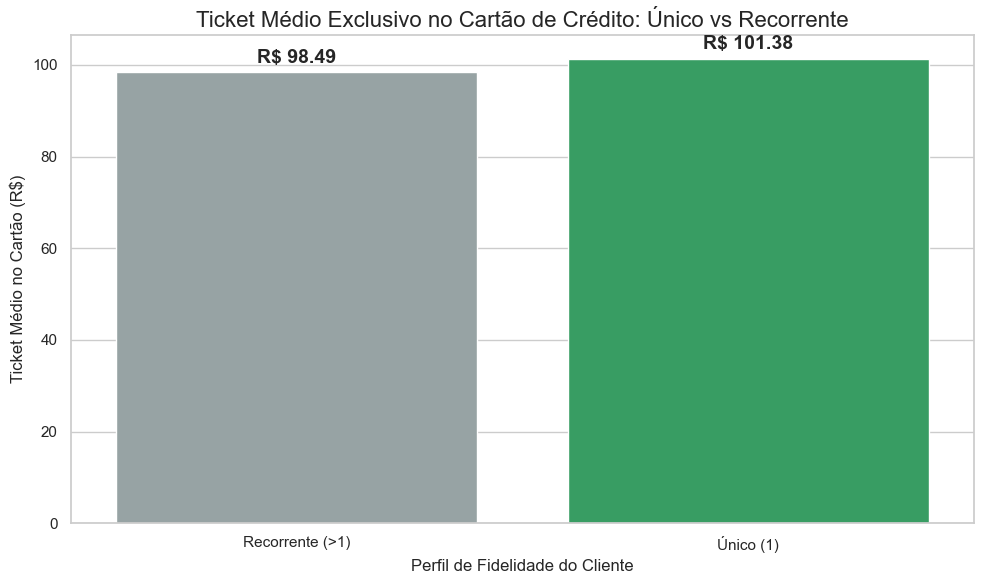

Média de Parcelas utilizadas (Confiança de Crédito na Plataforma):
- Cliente Recorrente (>1): 3.52 parcelas em média
- Cliente Único (1): 3.00 parcelas em média


In [189]:
# 1. Identificando clientes únicos vs recorrentes
frequencia = df_monetary_clean.groupby('customer_unique_id')['order_id'].nunique().reset_index()
frequencia.columns = ['customer_unique_id', 'total_pedidos']
frequencia['tipo_cliente'] = np.where(frequencia['total_pedidos'] > 1, 'Recorrente (>1)', 'Único (1)')

# 2. Mesclando a fidelidade com a base principal para obter o order_id
df_clientes = pd.merge(df_monetary_clean[['order_id', 'customer_unique_id']], frequencia, on='customer_unique_id', how='left')

# Removendo duplicatas de order_id para não inflar as médias
df_clientes = df_clientes.drop_duplicates(subset=['order_id'])

# 3. Cruzando os dados de fidelidade com os dados financeiros de pagamento
df_fidelidade_pag = pd.merge(df_clientes, df_pag_clean, on='order_id', how='inner')

# Filtrando APENAS pagamentos efetuados em Cartão de Crédito
df_fidelidade_credito = df_fidelidade_pag[df_fidelidade_pag['payment_type'] == 'credit_card']

# 4. Agrupamento: Ticket Médio no Cartão por Tipo de Cliente
ticket_fidelidade_cartao = df_fidelidade_credito.groupby('tipo_cliente')['payment_value'].mean().reset_index()

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=ticket_fidelidade_cartao, x='tipo_cliente', y='payment_value', palette=['#95a5a6', '#27ae60'])

plt.title('Ticket Médio Exclusivo no Cartão de Crédito: Único vs Recorrente', fontsize=16)
plt.xlabel('Perfil de Fidelidade do Cliente')
plt.ylabel('Ticket Médio no Cartão (R$)')

# Adicionando os valores absolutos nas barras
for index, value in enumerate(ticket_fidelidade_cartao['payment_value']):
    plt.text(index, value + 2, f'R$ {value:.2f}', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Verificando também a confiança em utilizar o parcelamento
parcelas_fidelidade = df_fidelidade_credito.groupby('tipo_cliente')['payment_installments'].mean().reset_index()
print("Média de Parcelas utilizadas (Confiança de Crédito na Plataforma):")
for _, row in parcelas_fidelidade.iterrows():
    print(f"- Cliente {row['tipo_cliente']}: {row['payment_installments']:.2f} parcelas em média")

**Percebemos que a fidelidade altera diretamente a propensão de risco de crédito.** Quando utiliza o Cartão de Crédito, o cliente Recorrente apresenta um Ticket Médio financeiro superior ao do cliente Único. Além disso, a análise revela que a confiança que o cliente adquire após a primeira compra bem-sucedida reflete-se no checkout: os clientes recorrentes sentem-se muito mais confortáveis em comprometer o limite do cartão em transações mais altas na plataforma.

**Primeiro, calculei a regra de fidelidade agrupando a quantidade de pedidos por customer_unique_id (separando "Único" e "Recorrente").** Juntei essa classificação à base de pagamentos através do identificador do pedido (order_id). Filtrei o dataset para analisar exclusivamente as transações efetuadas via Cartão de Crédito (credit_card). Agrupei os dois perfis calculando a média financeira gasta (payment_value) e plotei um gráfico de barras comparativo. No final, adicionei um relatório textual que extrai a média de parcelas que cada perfil utiliza.